In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm


**Instrucciones:**

Dado que el proceso de análisis es similar para los datos de temperatura, humedad y precipitaciones, vamos a utilizar un enfoque estandarizado. Primero, se analiza la variable de precipitaciones mensuales. Para ello, se desarrollan funciones específicas que permiten generar gráficos de manera eficiente. Estas funciones, una vez definidas, se aplicarán también a las otras dos variables (temperatura y humedad) para evitar redundancias y mantener consistencia en el análisis.

El proceso de análisis incluye los siguientes pasos:

1. **Creación de Gráficos Iniciales:** Primero, se generan gráficos que ilustran la serie temporal de precipitaciones mensuales. Estos gráficos serán similares a los presentados en la guía del documento DOCS, denominada "Análisis gráfico".

2. **Descomposición de la Serie Temporal:** Se procede a descomponer la serie temporal en sus componentes de estacionalidad y tendencia. Para ello, se crean gráficos adicionales que incluyen la función de autocorrelación (ACF) y la función de autocorrelación parcial (PACF).

3. **Aplicación del Modelo SARIMAX:** Se utiliza el modelo SARIMA (Seasonal AutoRegressive Integrated Moving Average), que es adecuado para series temporales con estacionalidad. Este modelo permite hacer predicciones basadas en la estacionalidad y la tendencia observadas en los datos.

4. **Gráficos de Predicciones:** Finalmente, se generan gráficos que muestran las predicciones realizadas por el modelo SARIMA a 1, 2 y 5 años.

Cada una de estas funciones de gráficos permite personalizar varios aspectos, como el título del gráfico, los nombres de los ejes X e Y, y las leyendas. De esta manera, puedes ajustar los nombres y etiquetas según tus preferencias para facilitar la interpretación de los resultados.


# Precipitaciones

In [2]:
df_precip_monthly = pd.read_csv('data/precipitaciones_mensual.csv')
df_precip_monthly

,year,Mes,Valor,month,date
0,1976,ENE,46.4,1,1976-01-01
1,1976,FEB,38.6,2,1976-02-01
2,1976,MAR,25.3,3,1976-03-01
3,1976,ABR,15.8,4,1976-04-01
4,1976,MAY,14.3,5,1976-05-01
...,...,...,...,...,...
527,2020,JUN,34.9,6,2020-06-01
528,2020,JUL,32.3,7,2020-07-01
529,2020,AGO,22.1,8,2020-08-01
530,2020,SEP,18.4,9,2020-09-01


In [3]:
df_precip_monthly['Valor'].max()

155.5

## Realizar gráficos

In [4]:
# Gráfico de líneas con los últimos 4 años presentes en el dataset. --------
def lineplot_series(df, title, xaxis, yaxis):
    # Configura el tamaño de la figura y crea la figura y los ejes
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Crea el gráfico utilizando seaborn
    sns.lineplot(data=df, x='year', y='Valor', ax=ax)
    
    # Etiquetas y título
    ax.set_xlabel(xaxis, fontsize=12)
    ax.set_ylabel(yaxis, fontsize=12)
    ax.set_title(title, fontsize=16)

    
    # Devuelve la figura y los ejes
    return fig, ax


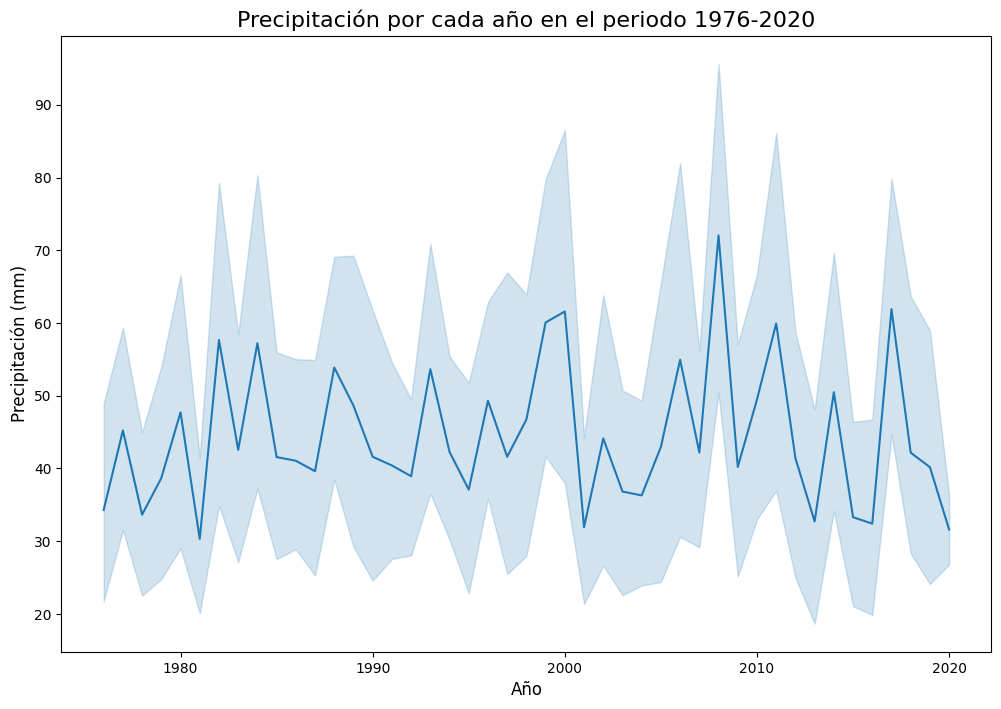

In [5]:
# Realizar gráficos
title = 'Precipitación por cada año en el periodo 1976-2020'
yaxis = 'Precipitación (mm)'
xaxis = 'Año'
legend_title = ''
fig, _ = lineplot_series(df_precip_monthly, title, xaxis, yaxis)

# Guardar figura
save_path = 'figs/precipitaciones/eda1.png'
fig.savefig(save_path) 

In [6]:
# Gráfico de líneas con los últimos 4 años presentes en el dataset. --------
def lineplot_last_4years(df, title, xaxis, yaxis, legend_title):
    
    # Filtrar los datos por los útlimos 4 años 
    ultimo_año = df['year'].max()
    df_last4_year = df.loc[df['year'] >= (ultimo_año - 4)]
    
    # Configura el tamaño de la figura y crea la figura y los ejes
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Crea el gráfico utilizando seaborn
    sns.lineplot(data=df_last4_year, x='Mes', y='Valor', hue='year', palette='tab10', ax=ax)
    
    # Etiquetas y título
    ax.set_xlabel(xaxis, fontsize=12)
    ax.set_ylabel(yaxis, fontsize=12)
    ax.set_title(title, fontsize=16)
    
    # Configura la leyenda
    ax.legend(title=legend_title, bbox_to_anchor=(0.5, -0.08), 
              loc='upper center', ncol=5, 
              frameon=False, fontsize=12)
    
    # Devuelve la figura y los ejes
    return fig, ax


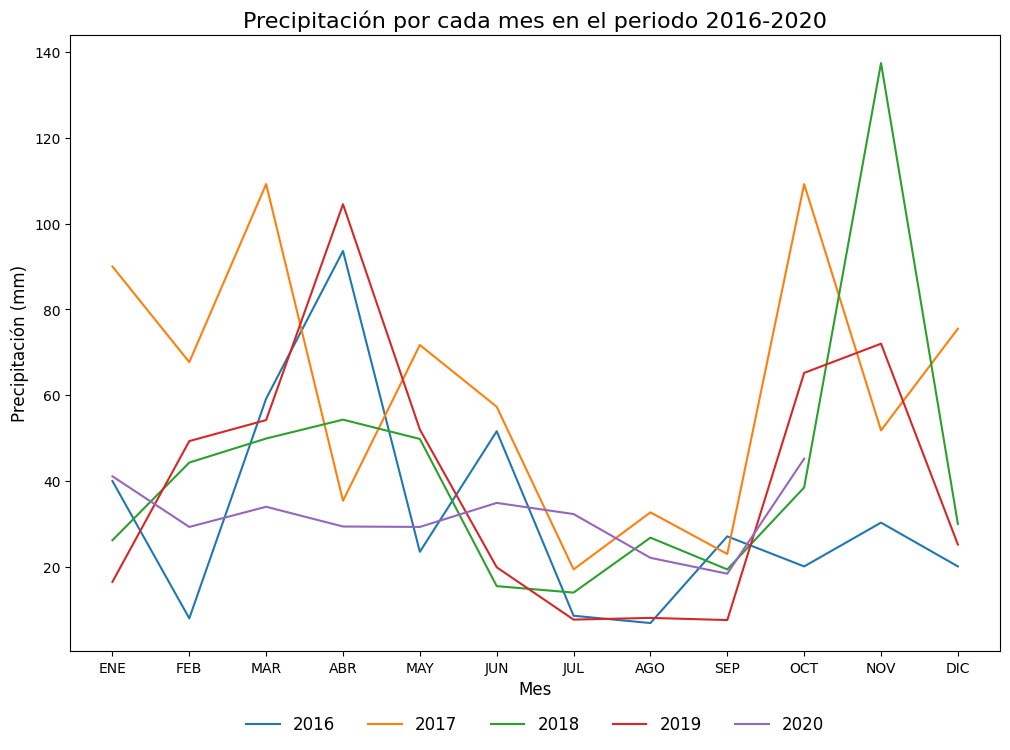

In [7]:
# Realizar gráficos
title = 'Precipitación por cada mes en el periodo 2016-2020'
yaxis = 'Precipitación (mm)'
xaxis = 'Mes'
legend_title = ''
fig, _ = lineplot_last_4years(df_precip_monthly, title, xaxis, yaxis, legend_title)

# Guardar figura
save_path = 'figs/precipitaciones/eda2.png'
fig.savefig(save_path) 

In [8]:
# Gráfico de líneas con las precipitaciones por rangos de años --------
def lineplot_by_ranges(df, title, xaxis, yaxis, legend_title):
    
    df['range'] = np.where((df['year'] >= 1976) & (df['year'] <= 1984), '1976-1984',
               np.where((df['year'] >= 1985) & (df['year'] <= 1993), '1985-1993',
               np.where((df['year'] >= 1994) & (df['year'] <= 2002), '1994-2002',
               np.where((df['year'] >= 2003) & (df['year'] <= 2011), '2003-2011', '2012-2020'))))
      
    # Configura el tamaño de la figura y crea la figura y los ejes
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Crea el gráfico utilizando seaborn
    sns.lineplot(data=df, x='Mes', y='Valor', hue='range', palette='tab10', ax=ax)
    
    # Etiquetas y título
    ax.set_xlabel(xaxis, fontsize=12)
    ax.set_ylabel(yaxis, fontsize=12)
    ax.set_title(title, fontsize=16)
    
    # Configura la leyenda
    ax.legend(title=legend_title, bbox_to_anchor=(0.5, -0.08), 
              loc='upper center', ncol=5, 
              frameon=False, fontsize=12)
    
    # Devuelve la figura y los ejes
    return fig, ax



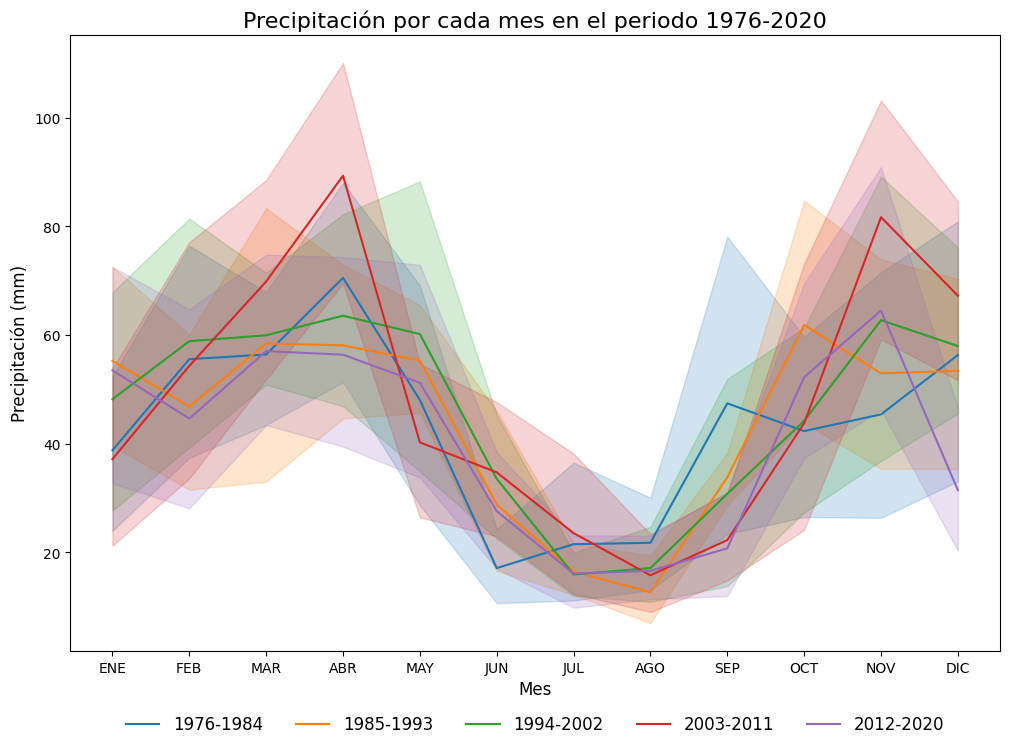

In [9]:
# Realizar gráficos
title = 'Precipitación por cada mes en el periodo 1976-2020'
yaxis = 'Precipitación (mm)'
xaxis = 'Mes'
legend_title = ''
fig, _ = lineplot_by_ranges(df_precip_monthly, title, xaxis, yaxis, legend_title)

# Guardar figura
save_path = 'figs/precipitaciones/eda3.png'
fig.savefig(save_path) 

In [10]:
# Gráfico de líneas con la media de precipitaciones por rangos de años --------
def lineplot_mean_by_ranges(df, title, xaxis, yaxis, legend_title):
    # Define the range categories
    df['range'] = np.where((df['year'] >= 1976) & (df['year'] <= 1984), '1976-1984',
               np.where((df['year'] >= 1985) & (df['year'] <= 1993), '1985-1993',
               np.where((df['year'] >= 1994) & (df['year'] <= 2002), '1994-2002',
               np.where((df['year'] >= 2003) & (df['year'] <= 2011), '2003-2011', '2012-2020'))))

    df = df.groupby(['Mes', 'range'])['Valor'].mean().reset_index()

    # Ensure 'Mes' is a categorical type with proper order
    month_order = ['ENE', 'FEB', 'MAR', 'ABR', 'MAY', 'JUN', 
                   'JUL', 'AGO', 'SEP', 'OCT', 'NOV', 'DIC']
    df['Mes'] = pd.Categorical(df['Mes'], categories=month_order, ordered=True)

    # Configura el tamaño de la figura y crea la figura y los ejes
    fig, ax = plt.subplots(figsize=(12, 8))

    # Crea el gráfico utilizando seaborn
    sns.lineplot(data=df, x='Mes', y='Valor', hue='range', palette='tab10', ax=ax)

    # Etiquetas y título
    ax.set_xlabel(xaxis, fontsize=12)
    ax.set_ylabel(yaxis, fontsize=12)
    ax.set_title(title, fontsize=16)

    # Configura la leyenda
    ax.legend(title=legend_title, bbox_to_anchor=(0.5, -0.08), 
              frameon=False, loc='upper center', ncol=5, fontsize=12)

    # Devuelve la figura y los ejes
    return fig, ax

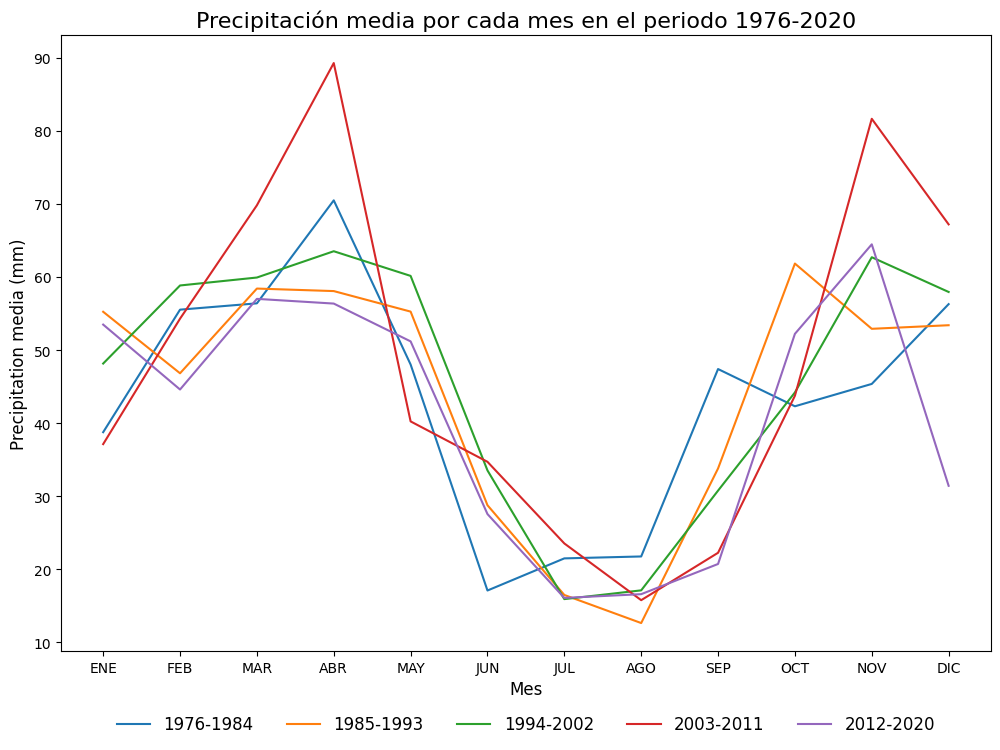

In [11]:
# Realizar gráficos
title = 'Precipitación media por cada mes en el periodo 1976-2020'
yaxis = 'Precipitation media (mm)'
xaxis = 'Mes'
legend_title = ''
fig, _ = lineplot_mean_by_ranges(df_precip_monthly, title, xaxis, yaxis, legend_title)

# Guardar figura
save_path = 'figs/precipitaciones/eda4.png'
fig.savefig(save_path) 

In [12]:
# Gráfico de líneas con la media de precipitaciones --------
def lineplot_mean(df, title, xaxis, yaxis):
    
    # Agrupar por la media
    df = df.groupby('Mes')['Valor'].mean().reset_index()
    
    # Ensure 'Mes' is a categorical type with proper order
    month_order = ['ENE', 'FEB', 'MAR', 'ABR', 'MAY', 'JUN', 
                   'JUL', 'AGO', 'SEP', 'OCT', 'NOV', 'DIC']
    
    df['Mes'] = pd.Categorical(df['Mes'], categories=month_order, ordered=True)
    # Configura el tamaño de la figura y crea la figura y los ejes
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Crea el gráfico utilizando seaborn
    sns.lineplot(data=df, x='Mes', y='Valor', ax=ax)
    
    # Etiquetas y título
    ax.set_xlabel(xaxis, fontsize=12)
    ax.set_ylabel(yaxis, fontsize=12)
    ax.set_title(title, fontsize=16)

    
    # Devuelve la figura y los ejes
    return fig, ax


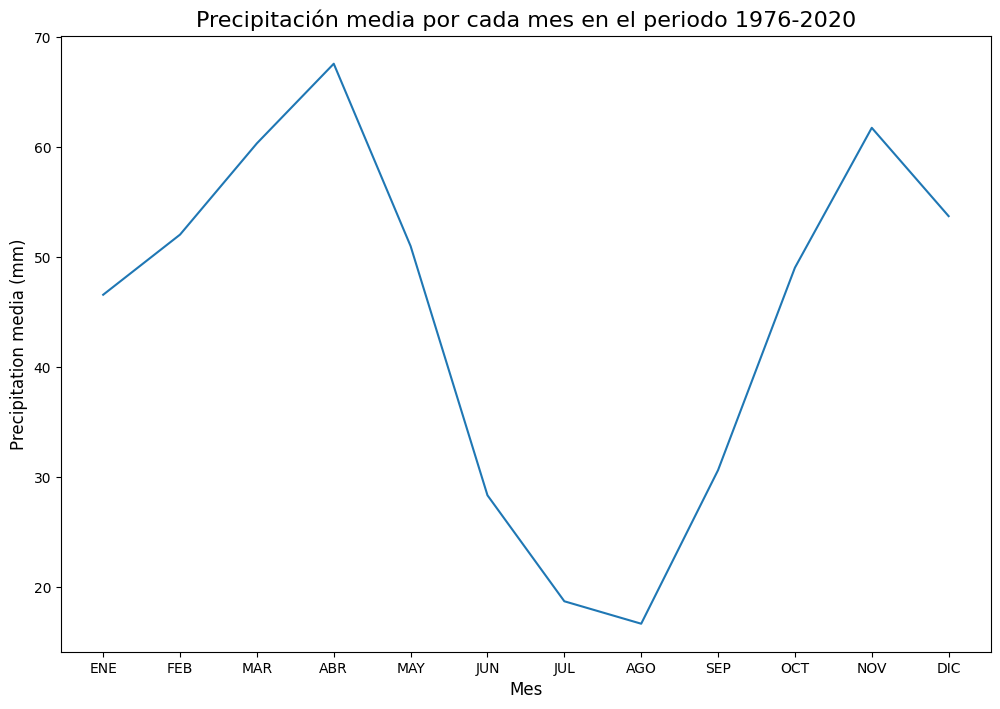

In [13]:
# Utilizar función
title = 'Precipitación media por cada mes en el periodo 1976-2020'
yaxis = 'Precipitation media (mm)'
xaxis = 'Mes'

fig, _ = lineplot_mean(df_precip_monthly, title, xaxis, yaxis)

# Guardar figura
save_path = 'figs/precipitaciones/eda5.png'
fig.savefig(save_path) 

## Analizando la serie temporal

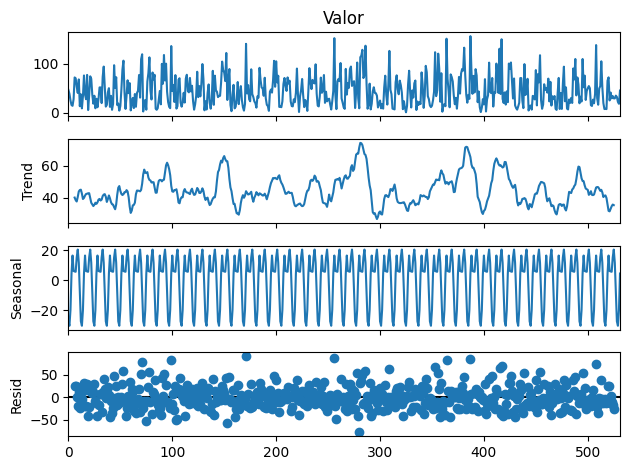

In [14]:
# Se descompone la serie temporal entre tendencia y estacionalidad
result = seasonal_decompose(df_precip_monthly['Valor'], model='additive', period=12)
result.plot()

# Guardar figura
save_path = 'figs/precipitaciones/model1.png'
plt.savefig(save_path) 

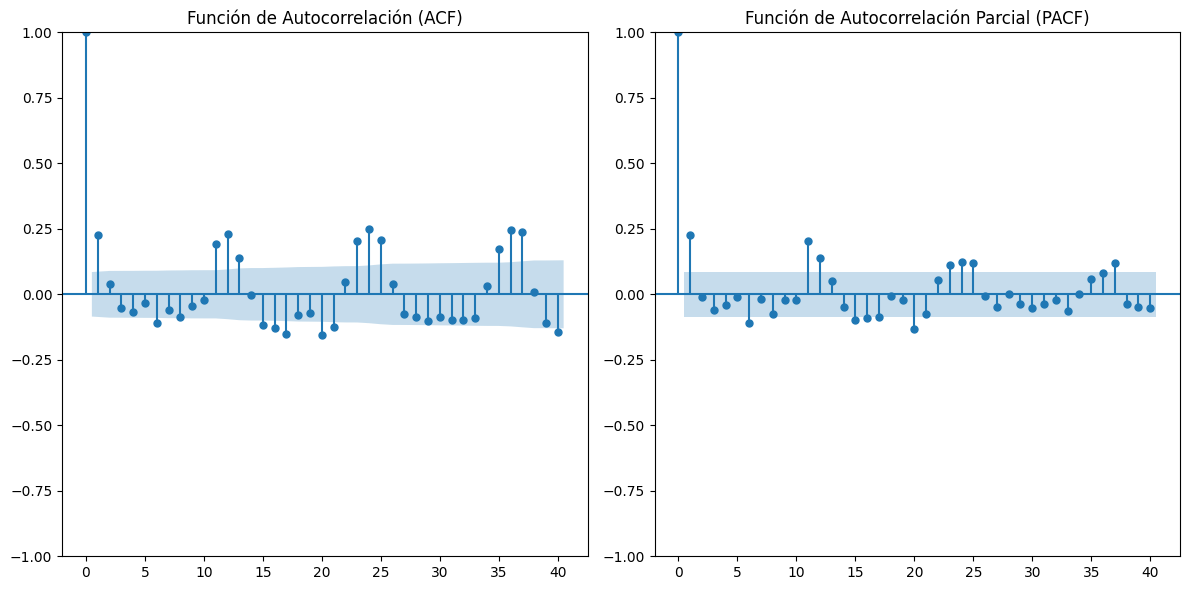

In [15]:
series = df_precip_monthly['Valor']

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plot_acf(series, ax=plt.gca(), lags=40)
plt.title('Función de Autocorrelación (ACF)')

# Gráfico de la PACF
plt.subplot(1, 2, 2)
plot_pacf(series, ax=plt.gca(), lags=40)
plt.title('Función de Autocorrelación Parcial (PACF)')

plt.tight_layout()

# Guardar figura
save_path = 'figs/precipitaciones/model2.png'
plt.savefig(save_path) 

## Creeando modelo SARIMA

In [16]:
# Para crear el modelo y evaluarlo, se divide el conjunto de datos en entrenamiento - prueba
# Luego, se crea el modelo y se realizan predicciones

df_precip_monthly = df_precip_monthly.rename(columns={'Valor': 'value'})

df_precip_monthly.index = pd.to_datetime(df_precip_monthly['date'])

# Dividir los datos en conjuntos de entrenamiento (80%) y prueba (20%)
train_size = int(len(df_precip_monthly) * 0.8)
train, test = df_precip_monthly[:train_size], df_precip_monthly[train_size:]

# Ajustar el modelo SARIMAX en el conjunto de entrenamiento
model = sm.tsa.statespace.SARIMAX(train['value'], order=(1, 1, 1), seasonal_order=(0, 1, 1, 12))
model_fit = model.fit()

model_fit.summary()

C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              value   No. Observations:                  425
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -1979.669
Date:                            Thu, 08 Aug 2024   AIC                           3967.338
Time:                                    09:04:10   BIC                           3983.422
Sample:                                         0   HQIC                          3973.700
                                            - 425                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0624      0.052      1.204      0.229      -0.039       0.164
ma.L1         -0.9998      0.690     -1.449      0.147      -2.353       0.353
ma.S.L12      -0.9102      0.030    -30.732      0.000      -0.968      -0.852
sigma2       809.9824    556.779      1.455      0.146    -281.284    1901.249
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                75.61
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               1.18   Skew:                             0.85
Prob(H) (two-sided):                  0.34   Kurtosis:                         4.22
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [17]:
def lineplot_predictions(test, model, df, title, xaxis, yaxis, legend_title):
    """
    En este gráfico se visualiza la serie completa desde 1976 - 2020.
    Para ello, se realizan las predicciones y se guardan en un dataframe, luego se grafican.
    Con dos colores se separan los datos reales y las predicciones realizadas por el modelo SARIMAX
    """
    # Hacer predicciones en el conjunto de prueba
    predictions = model.forecast(steps=len(test))

    # Crear un DataFrame para almacenar las predicciones y los valores reales
    pred_df = pd.DataFrame({'date': test.index, 'Real': test['value'].values, 'Predicciones': predictions})

    # Crear la figura y los ejes
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Graficar los valores reales vs las predicciones
    ax.plot(df.index, df['value'], label='Datos Reales')
    ax.plot(pred_df['date'], pred_df['Predicciones'], label='Predicciones')
    
    # Etiquetas y título
    ax.set_xlabel(xaxis, fontsize=12)
    ax.set_ylabel(yaxis, fontsize=12)
    ax.set_title(title, fontsize=16)

    ax.legend(title=legend_title, bbox_to_anchor=(0.5, -0.08), 
              loc='upper center', ncol=5, 
              frameon=False, fontsize=12)
    
    # Devolver la figura
    return fig, ax


C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


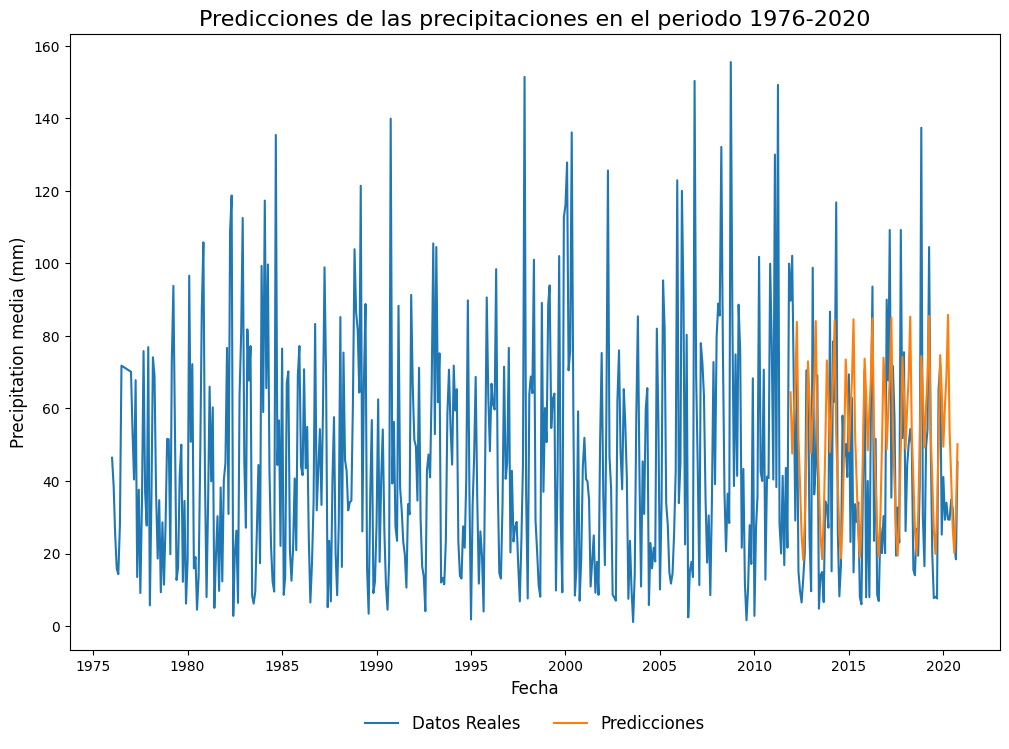

In [18]:
# Usar función

title = 'Predicciones de las precipitaciones en el periodo 1976-2020'
xaxis = 'Fecha'
yaxis = 'Precipitation media (mm)'
legend_title = ''
fig, _ = lineplot_predictions(test, model_fit, df_precip_monthly, title, xaxis, yaxis, legend_title)

# Guardar figura
save_path = 'figs/precipitaciones/model3.png'
plt.savefig(save_path) 

In [19]:
def lineplot_test_predictions(test, model, title, xaxis, yaxis, legend_title):
    """
    Mediante esta funcion se observan los datos reales vs las predcciones realizadas 
    solo para el conjunto de prueba (test)
    """
    # Hacer predicciones en el conjunto de prueba
    predictions = model.forecast(steps=len(test))

    # Crear un DataFrame para almacenar las predicciones y los valores reales
    pred_df = pd.DataFrame({'date': test.index, 'Real': test['value'].values, 'Predicciones': predictions})
    
    # Crear un DataFrame completo para graficar todos los datos, tanto reales como predicciones
    df_all = pd.concat([
        pd.DataFrame({'date': test.index, 'Tipo': 'Real', 'Valor': test['value'].values}),
        pd.DataFrame({'date': test.index, 'Tipo': 'Predicciones', 'Valor': predictions})
    ])

    # Configura el tamaño de la figura y crea la figura y los ejes
    fig, ax = plt.subplots(figsize=(12, 8))

    # Crea el gráfico utilizando seaborn
    sns.lineplot(data=df_all, x='date', y='Valor', hue='Tipo', ax=ax)

    # Etiquetas y título
    ax.set_xlabel(xaxis, fontsize=12)
    ax.set_ylabel(yaxis, fontsize=12)
    ax.set_title(title, fontsize=16)

    # Muestra la leyenda
    # Configura la leyenda
    ax.legend(title=legend_title, bbox_to_anchor=(0.5, -0.08), 
              loc='upper center', ncol=5, 
              frameon=False, fontsize=12)

    # Devuelve la figura y los ejes
    return fig, ax

C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


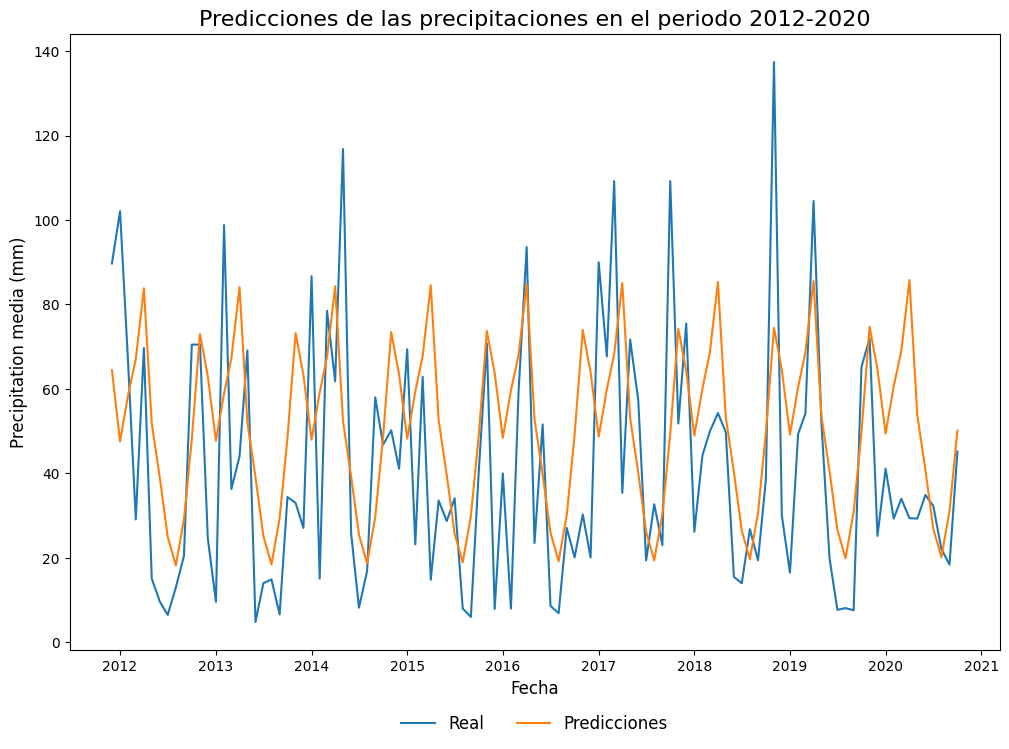

In [20]:
title = 'Predicciones de las precipitaciones en el periodo 2012-2020'
xaxis = 'Fecha'
yaxis = 'Precipitation media (mm)'
legend_title = ''
fig, ax = lineplot_test_predictions(test, model_fit, title, xaxis, yaxis, legend_title)

# Guardar figura
save_path = 'figs/precipitaciones/model4.png'
plt.savefig(save_path) 

In [21]:
def lineplot_predict_n_steps(test, model_fit, steps, title, xaxis, yaxis, legend_title, ax):
    """
    En esta función se grafica el modelo realizado y las predicciones n pasos en el futuro en el eje proporcionado.
    """
    # Hacer predicciones en el conjunto de prueba
    predictions = model_fit.forecast(steps=len(test))
    
    # Hacer predicciones a n pasos adelante
    forecast_n_steps = model_fit.get_forecast(steps=steps)
    forecast_n_steps_index = pd.date_range(start=test.index[-1] + pd.DateOffset(months=1), periods=steps, freq='ME')
    forecast_n_steps_values = forecast_n_steps.predicted_mean
    
    # Crear DataFrames para almacenar las predicciones y los valores reales
    pred_df = pd.DataFrame({'date': test.index, 'Real': test['value'].values, 'Predicciones': predictions})
    forecast_df = pd.DataFrame({'date': forecast_n_steps_index, 'Predicciones_12_steps': forecast_n_steps_values})
    
    # Graficar los valores reales vs las predicciones en el subplot
    ax.plot(test.index, test['value'], label='Datos Reales')
    ax.plot(pred_df['date'], pred_df['Predicciones'], label='Predicciones')
    ax.plot(forecast_df['date'], forecast_df['Predicciones_12_steps'], label=f'Pronóstico a {steps} meses', color='green', linestyle='--')
    
    ax.set_xlabel(xaxis, fontsize=12)
    ax.set_ylabel(yaxis, fontsize=12)
    ax.set_title(title, fontsize=16)
    ax.legend(title=legend_title, bbox_to_anchor=(0.5, -0.08), loc='upper center', ncol=5, frameon=False, fontsize=12)

C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


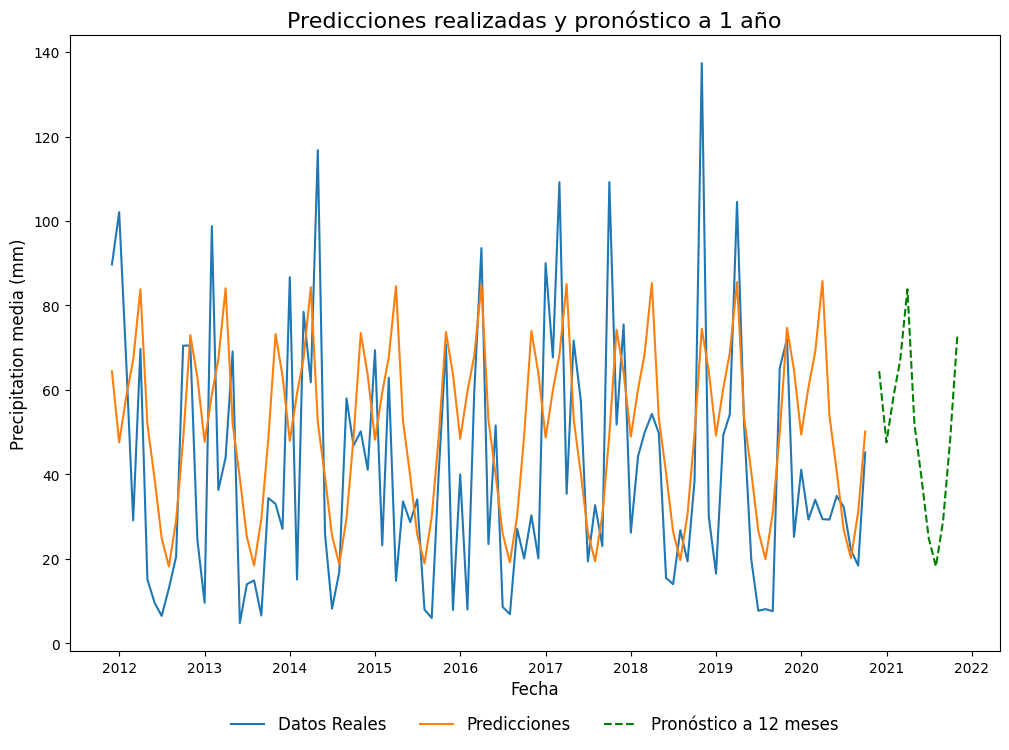

In [22]:
# PREDICCION A 1 AÑO

# Usar la función
fig, ax = plt.subplots(figsize=(12, 8))
title = 'Predicciones realizadas y pronóstico a 1 año'
xaxis = 'Fecha'
yaxis = 'Precipitation media (mm)'
legend_title = '' 
fig = lineplot_predict_n_steps(test, model_fit, 12, title, xaxis, yaxis, legend_title, ax)

# Guardar figura
save_path = 'figs/precipitaciones/model6.png'
plt.savefig(save_path) 

C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is avai

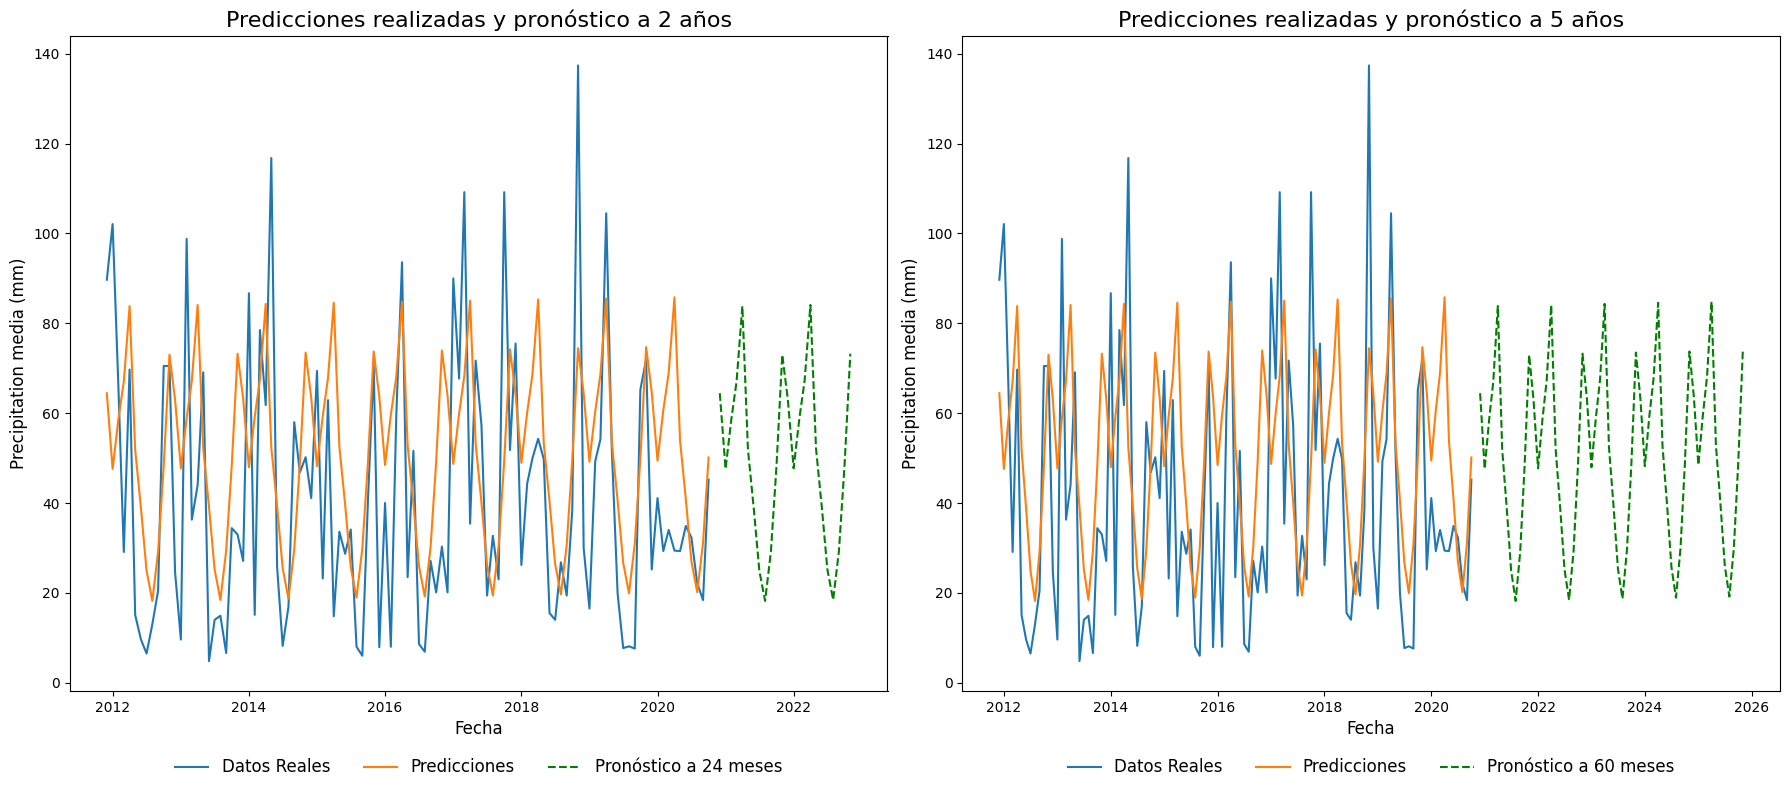

In [23]:
# Crear una figura con 2 subplots (1 fila, 2 columnas)
fig, axs = plt.subplots(1, 2, figsize=(18, 8))

# PREDICCION A 2 AÑOS
# Usar la función
title = 'Predicciones realizadas y pronóstico a 2 años'
xaxis = 'Fecha'
yaxis = 'Precipitation media (mm)'
legend_title = '' 
fig = lineplot_predict_n_steps(test, model_fit, 24, title, xaxis, yaxis, legend_title, axs[0])

# PREDICCION A 5 AÑOS

# Usar la función
title = 'Predicciones realizadas y pronóstico a 5 años'
xaxis = 'Fecha'
yaxis = 'Precipitation media (mm)'
legend_title = '' 
fig = lineplot_predict_n_steps(test, model_fit, 60, title, xaxis, yaxis, legend_title, axs[1])


# Ajustar layout para evitar solapamientos
plt.tight_layout()
save_path = 'figs/precipitaciones/model7.png'
plt.savefig(save_path)

# Temperatura

In [24]:
df_temp = pd.read_csv('data/temperaturas_mensual.csv')
df_temp

,year,Mes,Valor,month,date
0,1976,ENE,13.7,1,1976-01-01
1,1976,FEB,12.8,2,1976-02-01
2,1976,MAR,12.2,3,1976-03-01
3,1976,ABR,12.2,4,1976-04-01
4,1976,MAY,13.8,5,1976-05-01
...,...,...,...,...,...
526,2020,MAY,13.2,5,2020-05-01
527,2020,JUN,13.6,6,2020-06-01
528,2020,JUL,13.4,7,2020-07-01
529,2020,AGO,14.2,8,2020-08-01


## Realizar gráficos

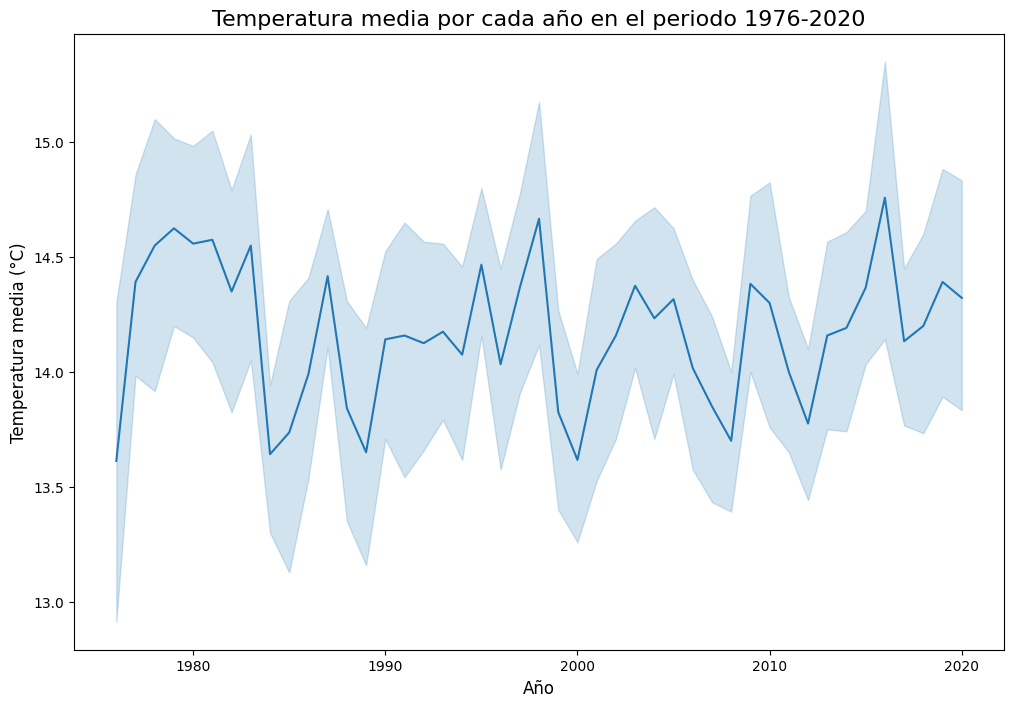

In [25]:
# Realizar gráficos
title = 'Temperatura media por cada año en el periodo 1976-2020'
yaxis = 'Temperatura media (°C)'
xaxis = 'Año'
legend_title = ''
fig, _ = lineplot_series(df_temp, title, xaxis, yaxis)

# Guardar igura
save_path = 'figs/temperatura/eda1.png'
fig.savefig(save_path) 

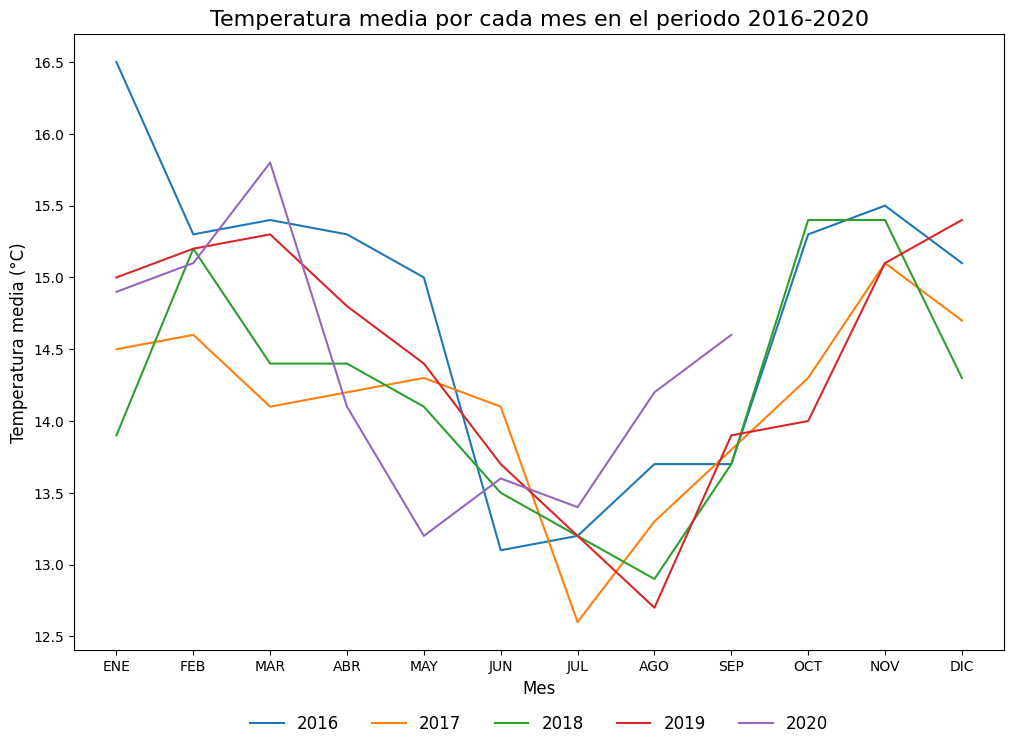

In [26]:
# Realizar gráficos
title = 'Temperatura media por cada mes en el periodo 2016-2020'
yaxis = 'Temperatura media (°C)'
xaxis = 'Mes'
legend_title = ''
fig, _ = lineplot_last_4years(df_temp, title, xaxis, yaxis, legend_title)

# Guardar figura
save_path = 'figs/temperatura/eda2.png'
fig.savefig(save_path) 

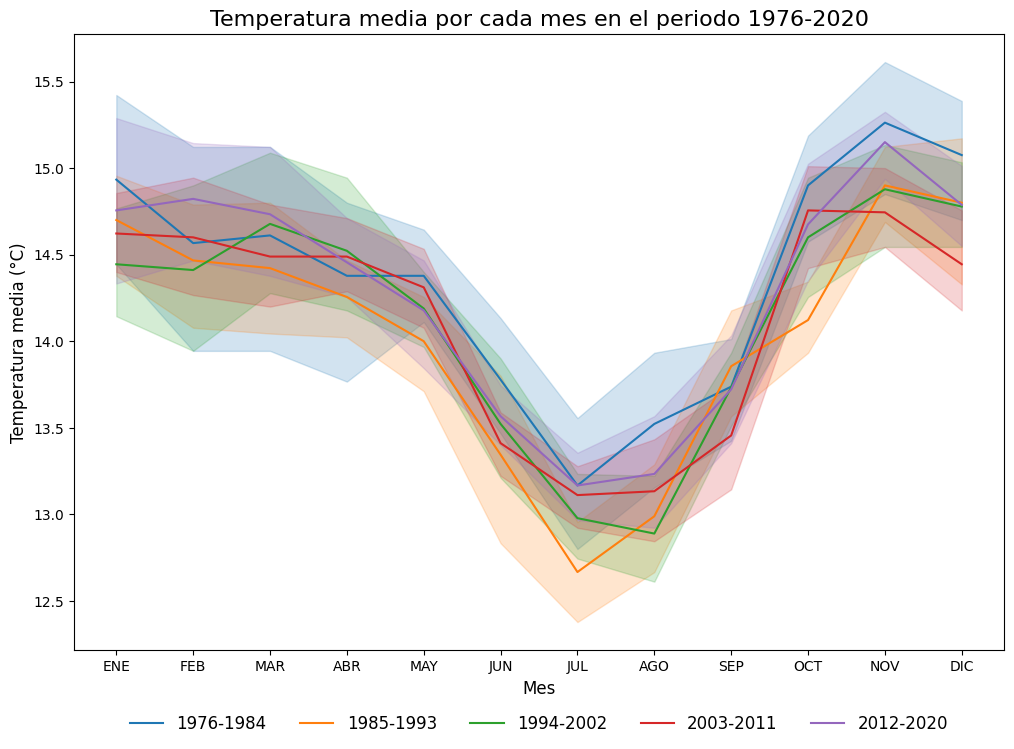

In [27]:
# Realizar gráficos
title = 'Temperatura media por cada mes en el periodo 1976-2020'
yaxis = 'Temperatura media (°C)'
xaxis = 'Mes'
legend_title = ''
fig, _ = lineplot_by_ranges(df_temp, title, xaxis, yaxis, legend_title)

# Guardar figura
save_path = 'figs/temperatura/eda3.png'
fig.savefig(save_path) 

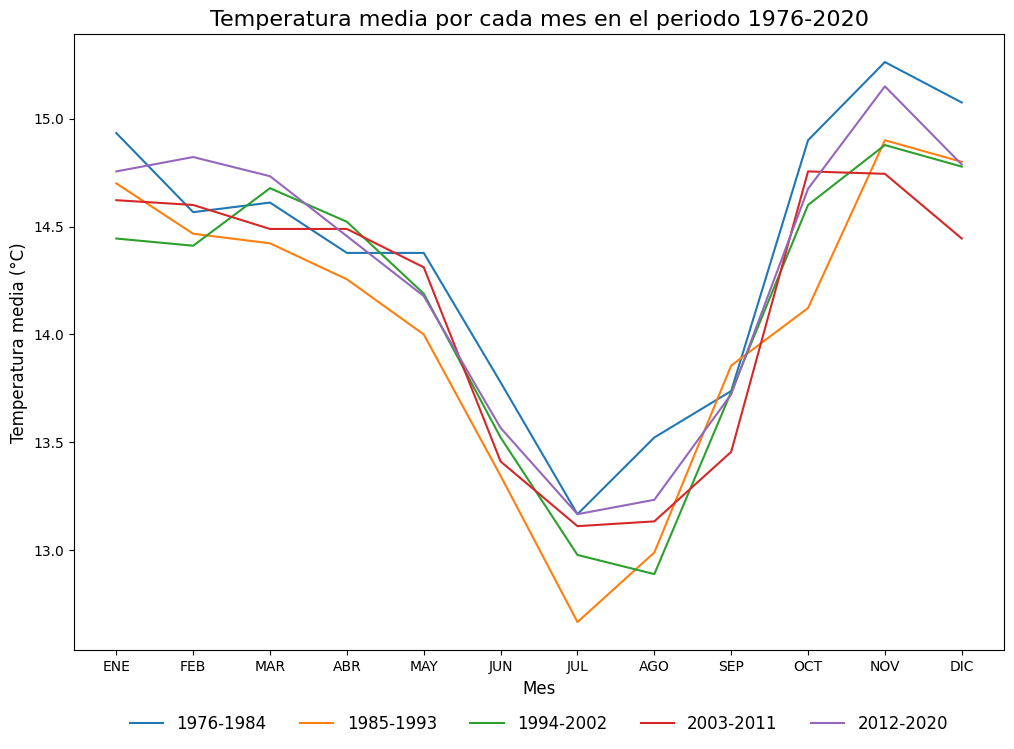

In [28]:
# Realizar gráficos
title = 'Temperatura media por cada mes en el periodo 1976-2020'
yaxis = 'Temperatura media (°C)'
xaxis = 'Mes'
legend_title = ''
fig, _ = lineplot_mean_by_ranges(df_temp, title, xaxis, yaxis, legend_title)

# Guardar figura
save_path = 'figs/temperatura/eda4.png'
fig.savefig(save_path) 

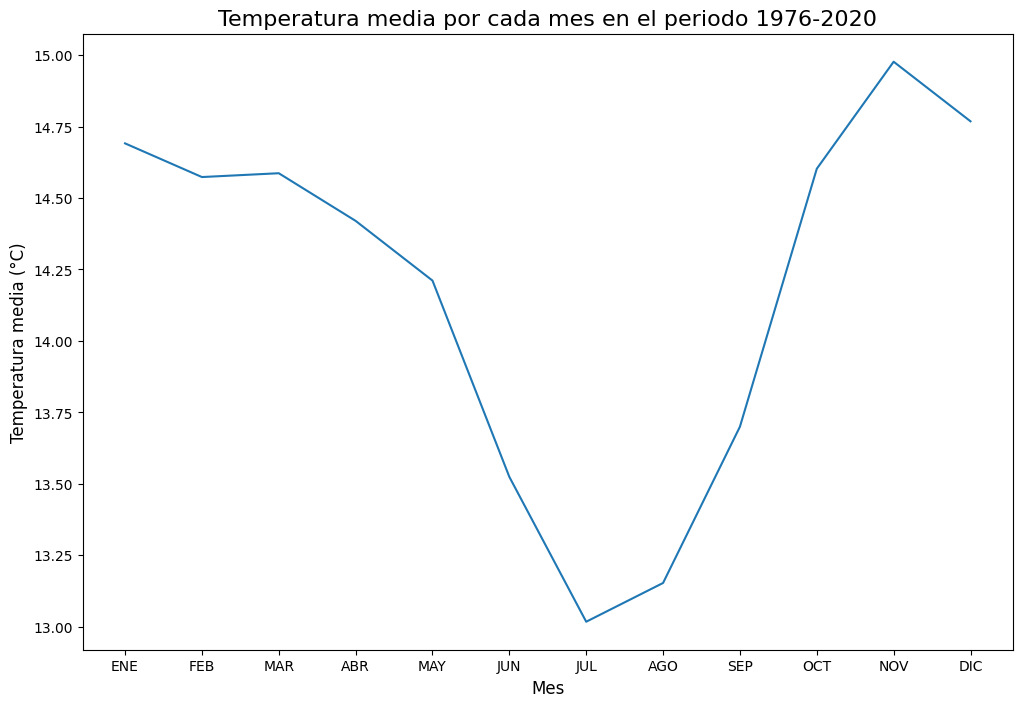

In [29]:
# Utilizar función
title = 'Temperatura media por cada mes en el periodo 1976-2020'
yaxis = 'Temperatura media (°C)'
xaxis = 'Mes'

fig, _ = lineplot_mean(df_temp, title, xaxis, yaxis)

# Guardar figura
save_path = 'figs/temperatura/eda5.png'
fig.savefig(save_path) 

## Analizando serie temporal

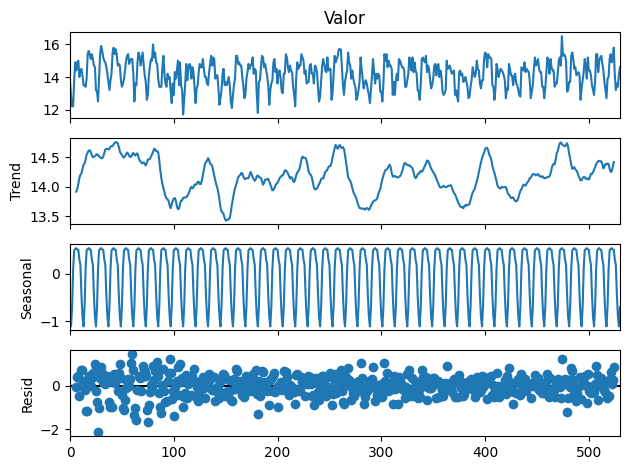

In [30]:
# Se descompone la serie temporal entre tendencia y estacionalidad
result = seasonal_decompose(df_temp['Valor'], model='additive', period=12)
result.plot()

# Guardar figura
save_path = 'figs/temperatura/model1.png'
plt.savefig(save_path) 

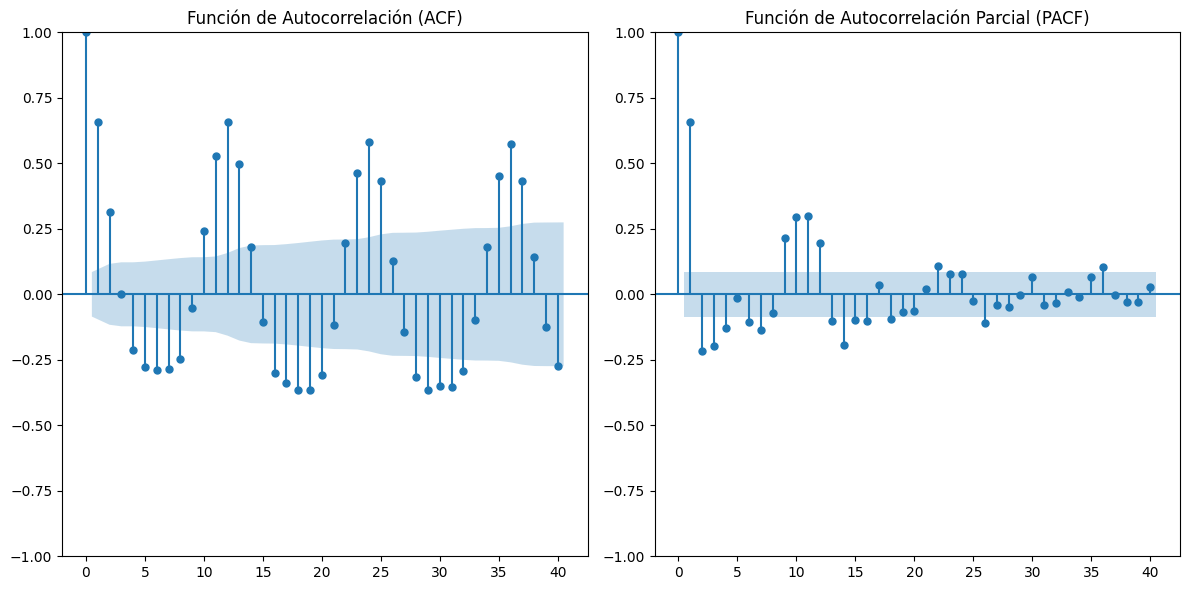

In [31]:
series = df_temp['Valor']

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plot_acf(series, ax=plt.gca(), lags=40)
plt.title('Función de Autocorrelación (ACF)')

# Gráfico de la PACF
plt.subplot(1, 2, 2)
plot_pacf(series, ax=plt.gca(), lags=40)
plt.title('Función de Autocorrelación Parcial (PACF)')

plt.tight_layout()
save_path = 'figs/temperatura/model2.png'
plt.savefig(save_path) 

## Creando modelo SARIMA

In [32]:
# Para crear el modelo y evaluarlo, se divide el conjunto de datos en entrenamiento - prueba
# Luego, se crea el modelo y se realizan predicciones

df_temp = df_temp.rename(columns={'Valor': 'value'})

df_temp.index = pd.to_datetime(df_temp['date'])

# Dividir los datos en conjuntos de entrenamiento (80%) y prueba (20%)
train_size = int(len(df_temp) * 0.8)
train, test = df_temp[:train_size], df_temp[train_size:]

# Ajustar el modelo SARIMAX en el conjunto de entrenamiento
model = sm.tsa.statespace.SARIMAX(train['value'], order=(1, 1, 1), seasonal_order=(0, 1, 1, 12))
model_fit = model.fit()

model_fit.summary()

C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              value   No. Observations:                  424
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -299.360
Date:                            Thu, 08 Aug 2024   AIC                            606.719
Time:                                    09:04:19   BIC                            622.794
Sample:                                         0   HQIC                           613.078
                                            - 424                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2864      0.064      4.489      0.000       0.161       0.411
ma.L1         -0.8365      0.042    -20.000      0.000      -0.918      -0.754
ma.S.L12      -0.7261      0.035    -20.981      0.000      -0.794      -0.658
sigma2         0.2453      0.018     13.719      0.000       0.210       0.280
===================================================================================
Ljung-Box (L1) (Q):                   0.09   Jarque-Bera (JB):                 0.43
Prob(Q):                              0.77   Prob(JB):                         0.81
Heteroskedasticity (H):               0.66   Skew:                            -0.08
Prob(H) (two-sided):                  0.02   Kurtosis:                         3.01
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


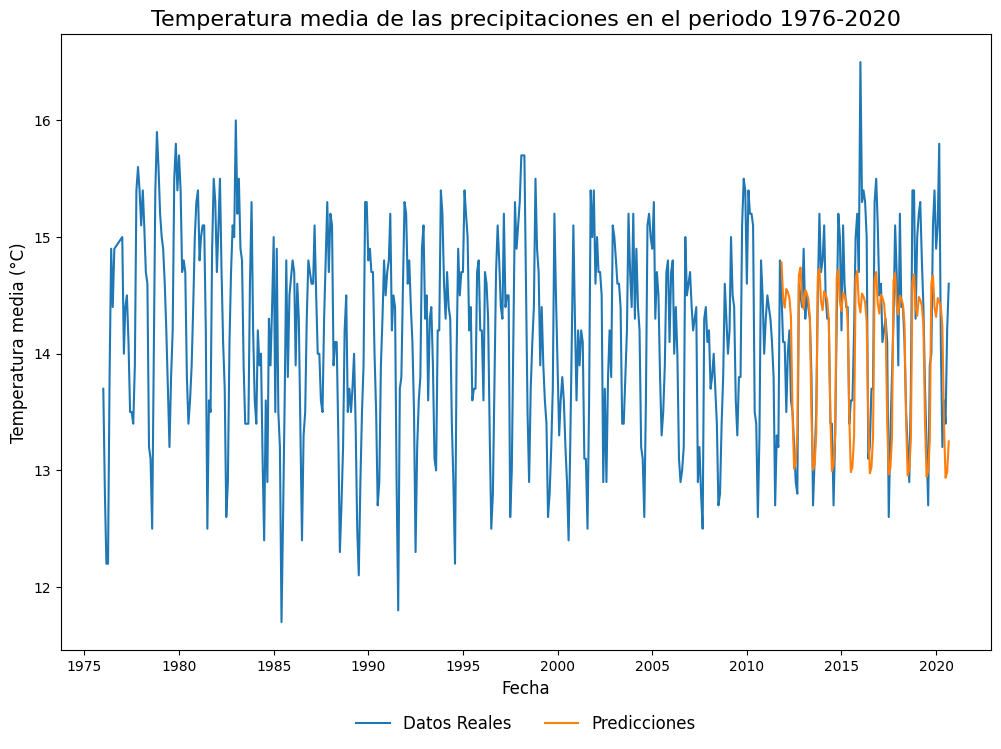

In [33]:
# Usar función

title = 'Temperatura media de las precipitaciones en el periodo 1976-2020'
xaxis = 'Fecha'
yaxis = 'Temperatura media (°C)'
legend_title = ''
fig, _ = lineplot_predictions(test, model_fit, df_temp, title, xaxis, yaxis, legend_title)

# Guardar figura
save_path = 'figs/temperatura/model3.png'
plt.savefig(save_path) 

C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


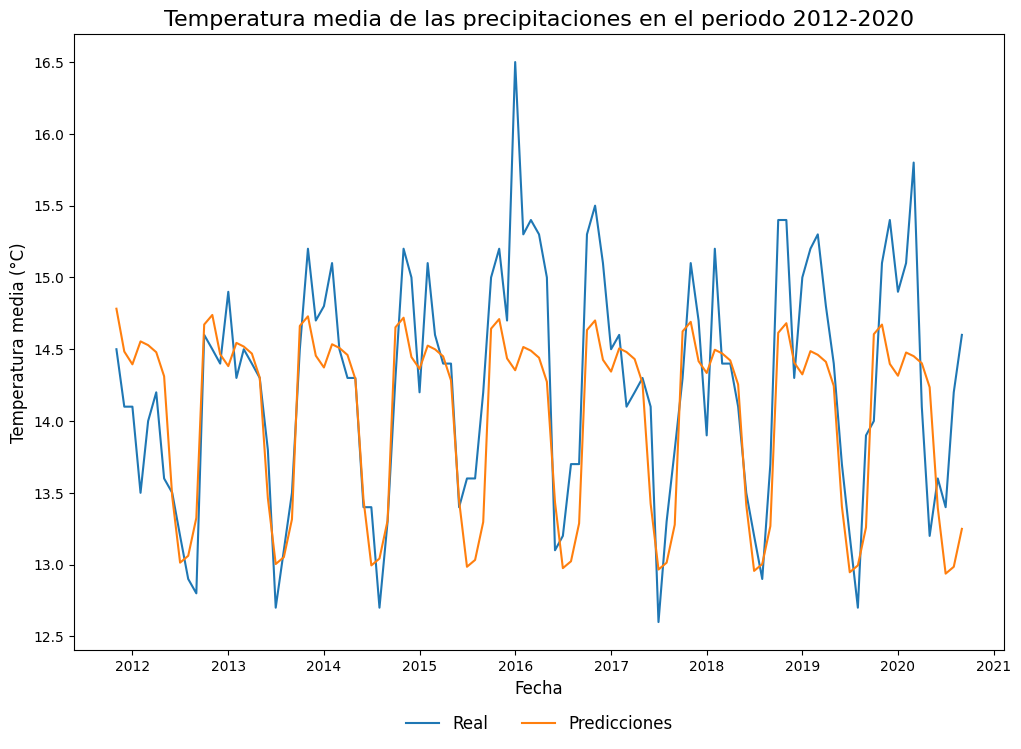

In [34]:
title = 'Temperatura media de las precipitaciones en el periodo 2012-2020'
xaxis = 'Fecha'
yaxis = 'Temperatura media (°C)'
legend_title = ''
fig, ax = lineplot_test_predictions(test, model_fit, title, xaxis, yaxis, legend_title)

# Guardar figura
save_path = 'figs/temperatura/model4.png'
plt.savefig(save_path) 

C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


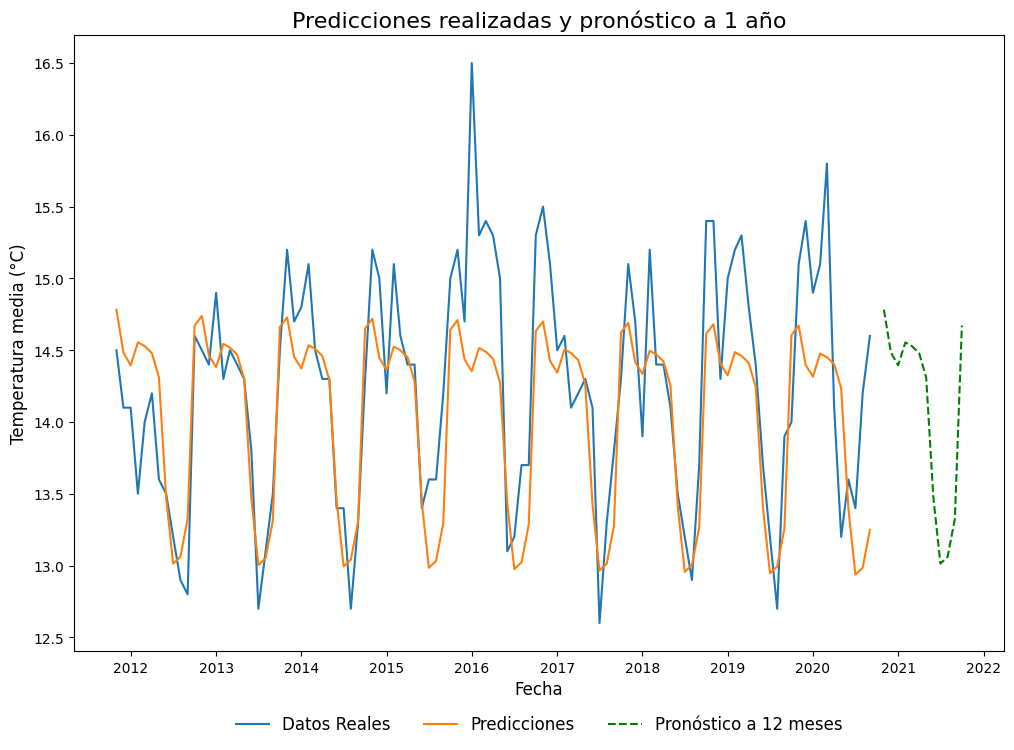

In [35]:
# PREDICCION A 1 AÑO

# Usar la función
fig, ax = plt.subplots(figsize=(12, 8))
title = 'Predicciones realizadas y pronóstico a 1 año'
xaxis = 'Fecha'
yaxis = 'Temperatura media (°C)'
legend_title = '' 
fig = lineplot_predict_n_steps(test, model_fit, 12, title, xaxis, yaxis, legend_title, ax)

# Guardar figura
save_path = 'figs/temperatura/model6.png'
plt.savefig(save_path) 

C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is avai

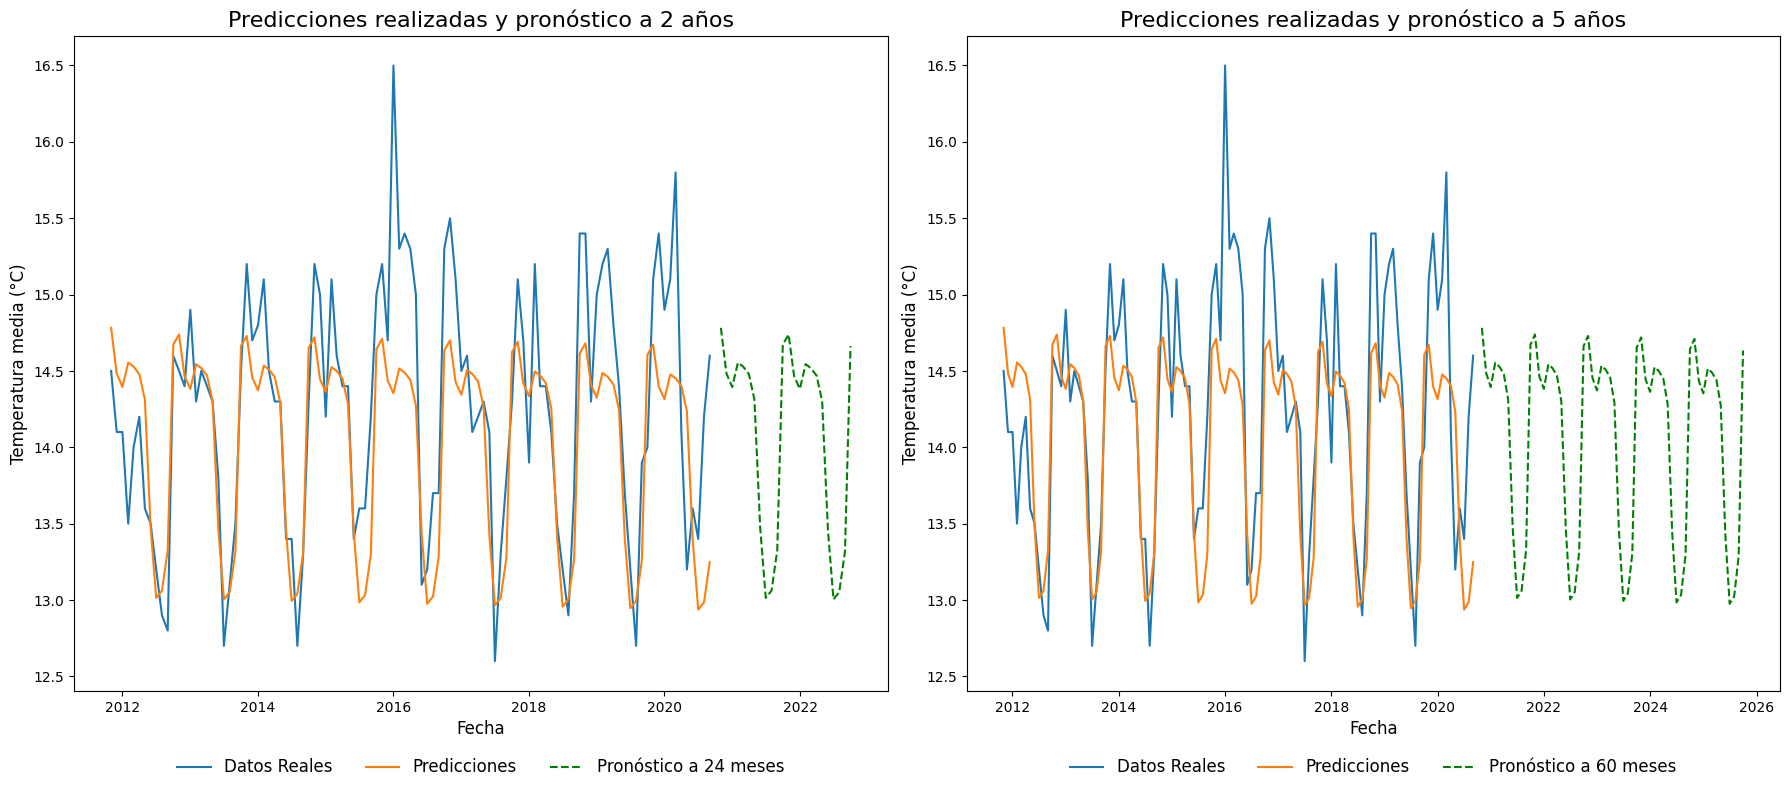

In [36]:
# Crear una figura con 2 subplots (1 fila, 2 columnas)
fig, axs = plt.subplots(1, 2, figsize=(18, 8))

# PREDICCION A 2 AÑOS

# Usar la función
title = 'Predicciones realizadas y pronóstico a 2 años'
xaxis = 'Fecha'
yaxis = 'Temperatura media (°C)'
legend_title = '' 
fig = lineplot_predict_n_steps(test, model_fit, 24, title, xaxis, yaxis, legend_title, axs[0])

# PREDICCION A 5 AÑOS

# Usar la función
# Usar la función
title = 'Predicciones realizadas y pronóstico a 5 años'
xaxis = 'Fecha'
yaxis = 'Temperatura media (°C)'
legend_title = '' 
fig = lineplot_predict_n_steps(test, model_fit, 60, title, xaxis, yaxis, legend_title, axs[1])


# Ajustar layout para evitar solapamientos
plt.tight_layout()
save_path = 'figs/temperatura/model7.png'
plt.savefig(save_path)

# Humedad relativa

In [37]:
df_humedad = pd.read_csv('data/humedad_mensual.csv')
df_humedad

,year,Mes,Valor,month,date
0,1976,ENE,76.0,1,1976-01-01
1,1976,FEB,76.0,2,1976-02-01
2,1976,MAR,73.0,3,1976-03-01
3,1976,ABR,73.0,4,1976-04-01
4,1976,MAY,70.0,5,1976-05-01
...,...,...,...,...,...
525,2020,MAY,80.0,5,2020-05-01
526,2020,JUN,75.0,6,2020-06-01
527,2020,JUL,77.0,7,2020-07-01
528,2020,AGO,74.0,8,2020-08-01


## Realizar gráficos

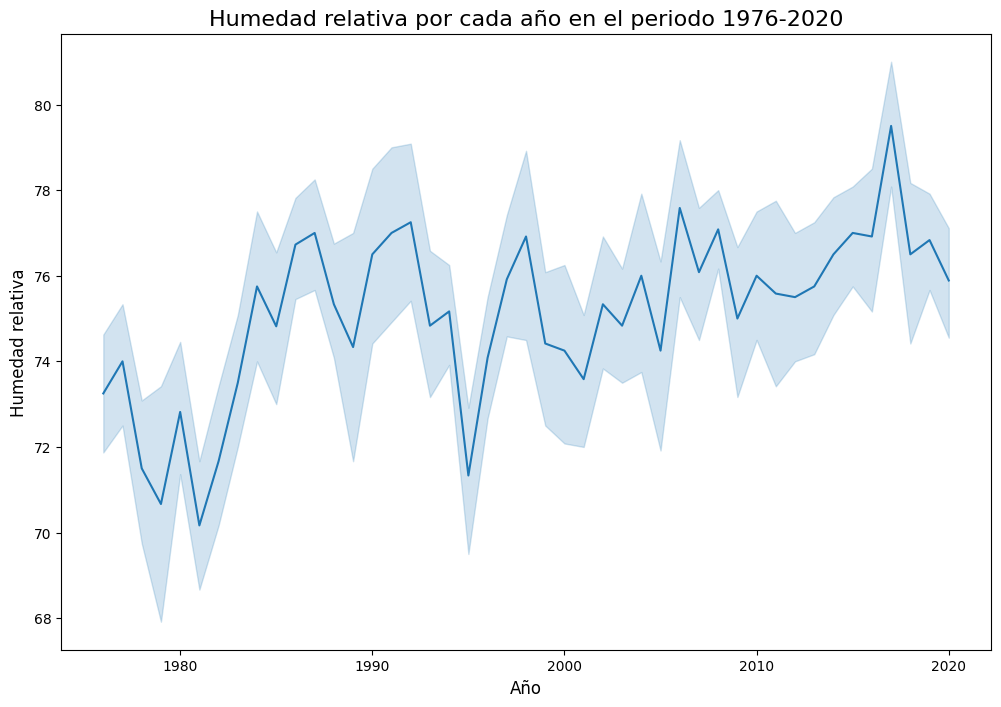

In [38]:
# Realizar gráficos
title = 'Humedad relativa por cada año en el periodo 1976-2020'
yaxis = 'Humedad relativa'
xaxis = 'Año'
legend_title = ''
fig, _ = lineplot_series(df_humedad, title, xaxis, yaxis)

# Guardar igura
save_path = 'figs/humedad/eda1.png'
fig.savefig(save_path) 


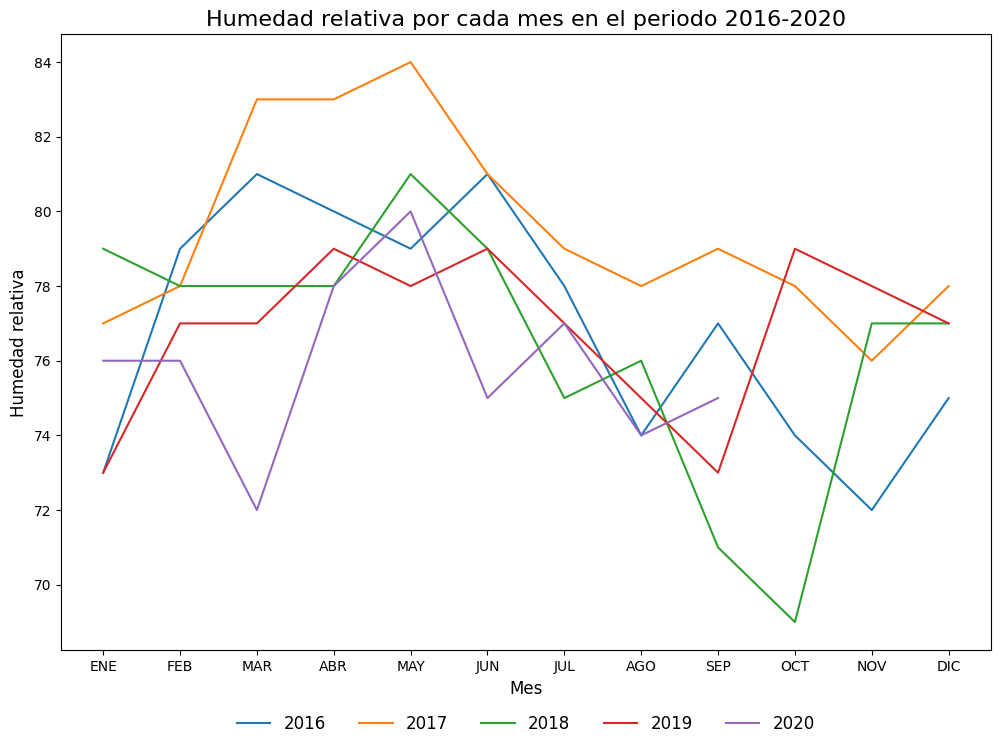

In [39]:
# Realizar gráficos
title = 'Humedad relativa por cada mes en el periodo 2016-2020'
yaxis = 'Humedad relativa'
xaxis = 'Mes'
legend_title = ''
fig, _ = lineplot_last_4years(df_humedad, title, xaxis, yaxis, legend_title)

# Guardar figura
save_path = 'figs/humedad/eda2.png'
fig.savefig(save_path) 

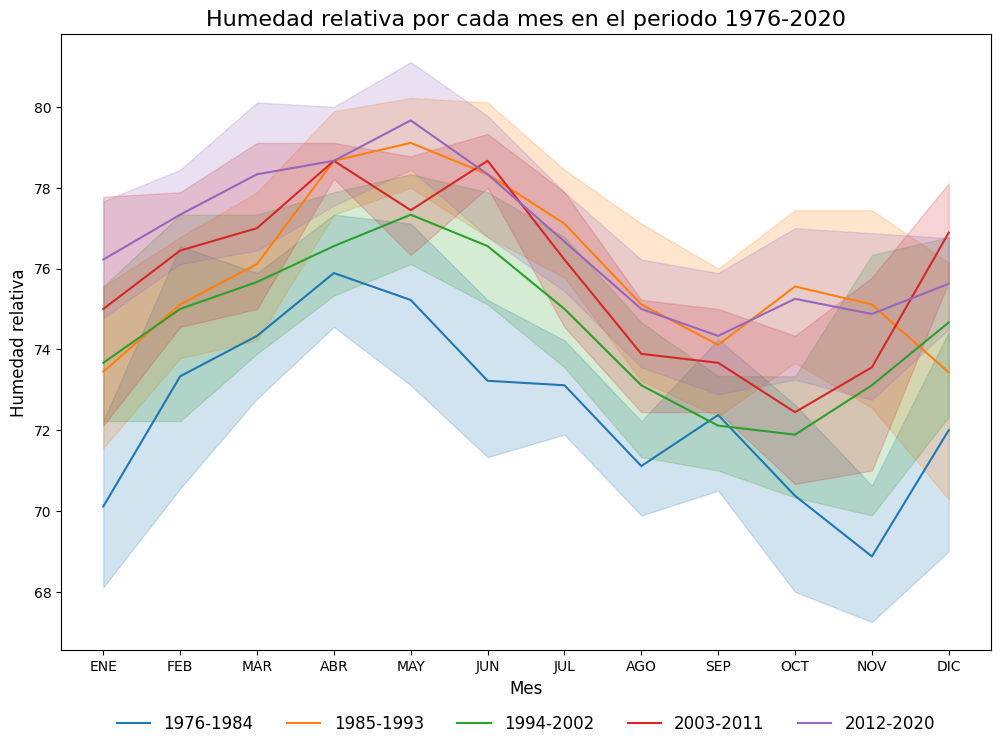

In [40]:
# Realizar gráficos
title = 'Humedad relativa por cada mes en el periodo 1976-2020'
yaxis = 'Humedad relativa'
xaxis = 'Mes'
legend_title = ''
fig, _ = lineplot_by_ranges(df_humedad, title, xaxis, yaxis, legend_title)

# Guardar figura
save_path = 'figs/humedad/eda3.png'
fig.savefig(save_path) 


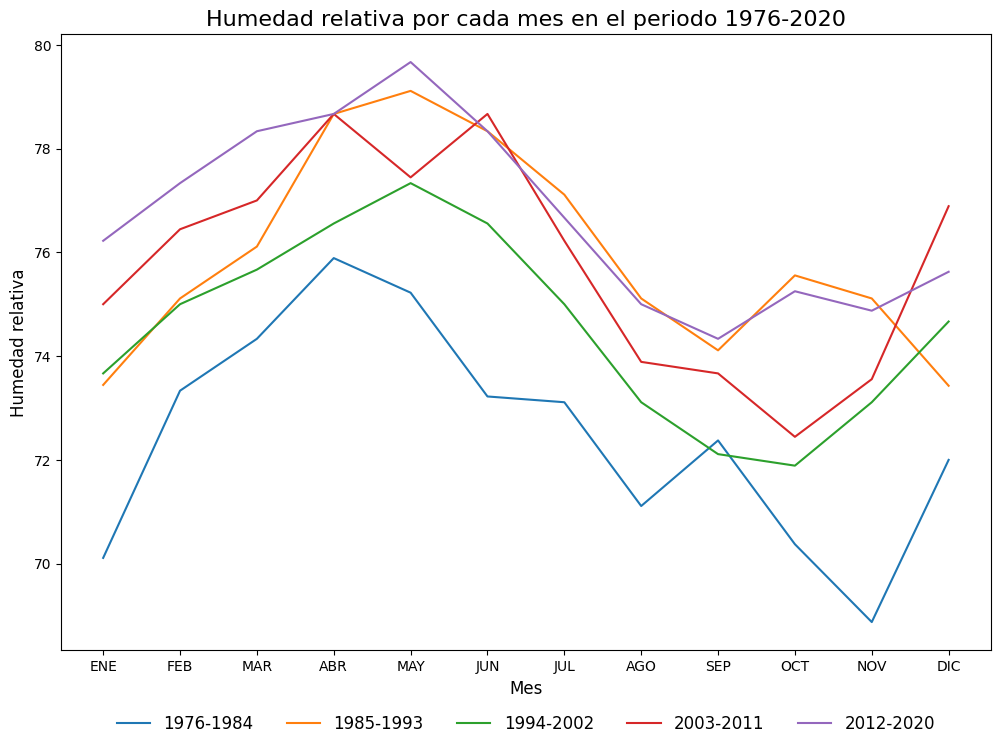

In [41]:
# Realizar gráficos
title = 'Humedad relativa por cada mes en el periodo 1976-2020'
yaxis = 'Humedad relativa'
xaxis = 'Mes'
legend_title = ''
fig, _ = lineplot_mean_by_ranges(df_humedad, title, xaxis, yaxis, legend_title)

# Guardar figura
save_path = 'figs/humedad/eda4.png'
fig.savefig(save_path) 

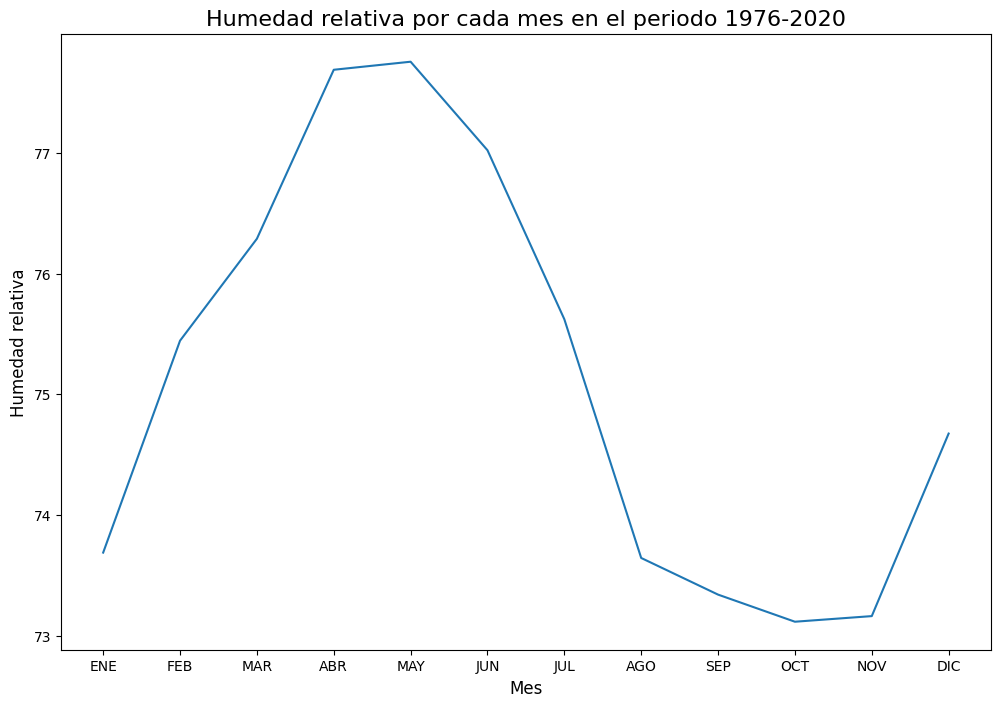

In [42]:
# Utilizar función
title = 'Humedad relativa por cada mes en el periodo 1976-2020'
yaxis = 'Humedad relativa'
xaxis = 'Mes'

fig, _ = lineplot_mean(df_humedad, title, xaxis, yaxis)

# Guardar figura
save_path = 'figs/humedad/eda5.png'
fig.savefig(save_path) 

## Analizando la serie temporal

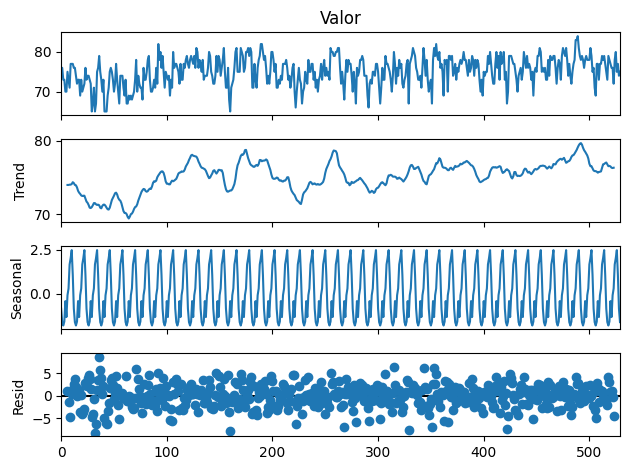

In [43]:
# Se descompone la serie temporal entre tendencia y estacionalidad
result = seasonal_decompose(df_humedad['Valor'], model='additive', period=12)
result.plot()

# Guardar figura
save_path = 'figs/humedad/model1.png'
plt.savefig(save_path) 

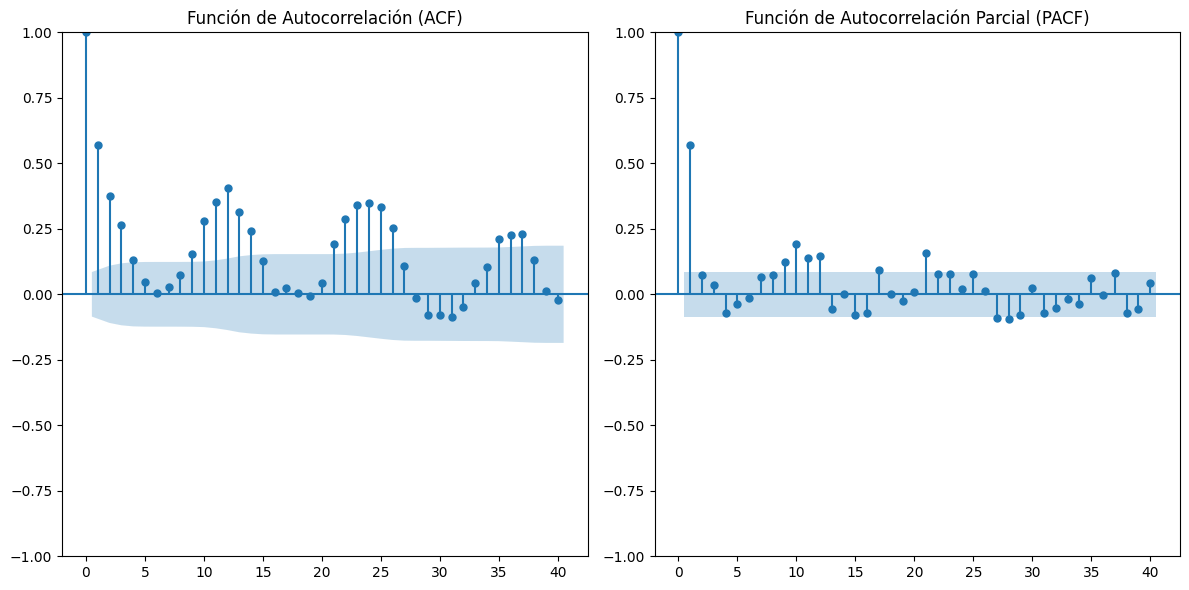

In [44]:
# Se observan graficos de ACF y PACF, ademas de la diferenciación de la serie
series = df_humedad['Valor']

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plot_acf(series, ax=plt.gca(), lags=40)
plt.title('Función de Autocorrelación (ACF)')

# Gráfico de la PACF
plt.subplot(1, 2, 2)
plot_pacf(series, ax=plt.gca(), lags=40)
plt.title('Función de Autocorrelación Parcial (PACF)')

plt.tight_layout()
save_path = 'figs/humedad/model2.png'
plt.savefig(save_path) 

## Creando modelo SARIMA

In [45]:
# Para crear el modelo y evaluarlo, se divide el conjunto de datos en entrenamiento - prueba
# Luego, se crea el modelo y se realizan predicciones

df_humedad = df_humedad.rename(columns={'Valor': 'value'})

df_humedad.index = pd.to_datetime(df_humedad['date'])

# Dividir los datos en conjuntos de entrenamiento (80%) y prueba (20%)
train_size = int(len(df_humedad) * 0.8)
train, test = df_humedad[:train_size], df_humedad[train_size:]

# Ajustar el modelo SARIMAX en el conjunto de entrenamiento
model = sm.tsa.statespace.SARIMAX(train['value'], order=(1, 1, 1), seasonal_order=(0, 1, 1, 12))
model_fit = model.fit()

model_fit.summary()

C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              value   No. Observations:                  424
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -1031.864
Date:                            Thu, 08 Aug 2024   AIC                           2071.729
Time:                                    09:04:28   BIC                           2087.803
Sample:                                         0   HQIC                          2078.088
                                            - 424                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3526      0.055      6.421      0.000       0.245       0.460
ma.L1         -0.9247      0.024    -37.909      0.000      -0.973      -0.877
ma.S.L12      -0.8788      0.032    -27.085      0.000      -0.942      -0.815
sigma2         8.4570      0.547     15.463      0.000       7.385       9.529
===================================================================================
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):                 3.22
Prob(Q):                              0.73   Prob(JB):                         0.20
Heteroskedasticity (H):               1.02   Skew:                            -0.08
Prob(H) (two-sided):                  0.92   Kurtosis:                         3.40
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


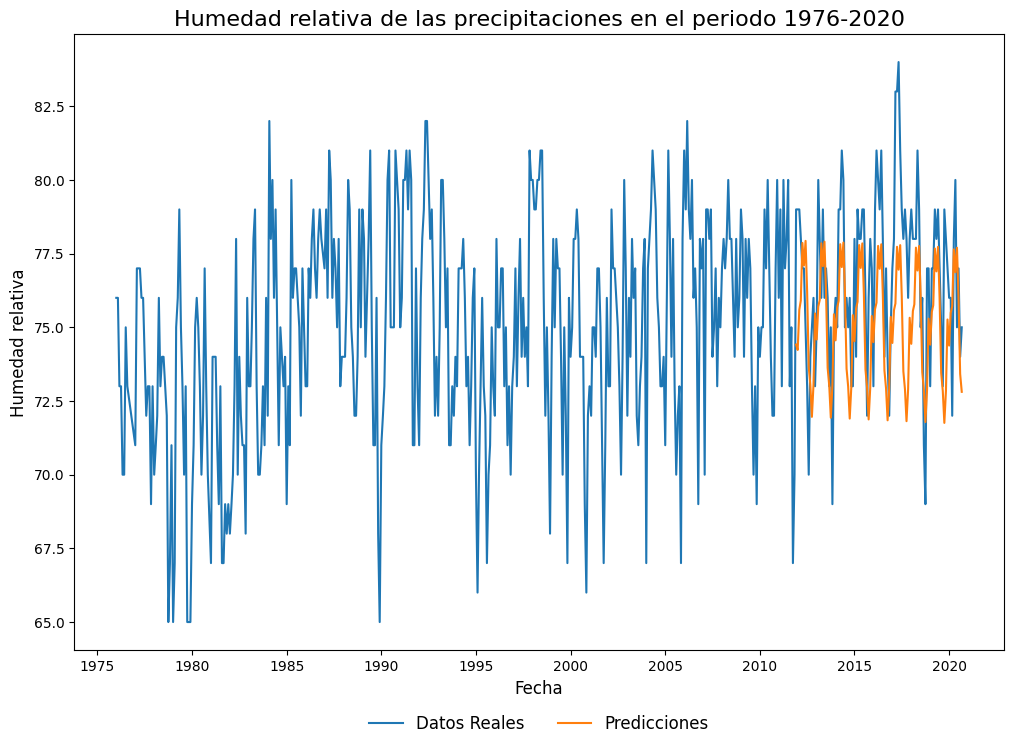

In [46]:
# Usar función

title = 'Humedad relativa de las precipitaciones en el periodo 1976-2020'
xaxis = 'Fecha'
yaxis = 'Humedad relativa'
legend_title = ''
fig, _ = lineplot_predictions(test, model_fit, df_humedad, title, xaxis, yaxis, legend_title)

# Guardar figura
save_path = 'figs/humedad/model3.png'
plt.savefig(save_path) 

C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


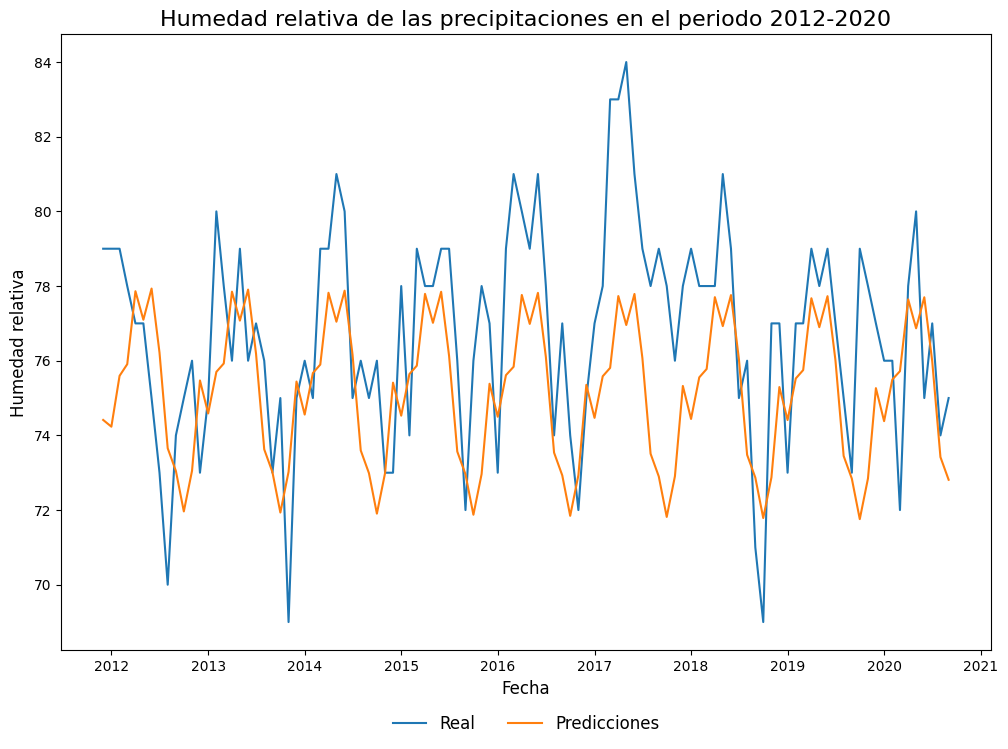

In [47]:
title = 'Humedad relativa de las precipitaciones en el periodo 2012-2020'
xaxis = 'Fecha'
yaxis = 'Humedad relativa'
legend_title = ''
fig, ax = lineplot_test_predictions(test, model_fit, title, xaxis, yaxis, legend_title)

# Guardar figura
save_path = 'figs/humedad/model4.png'
plt.savefig(save_path) 

C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


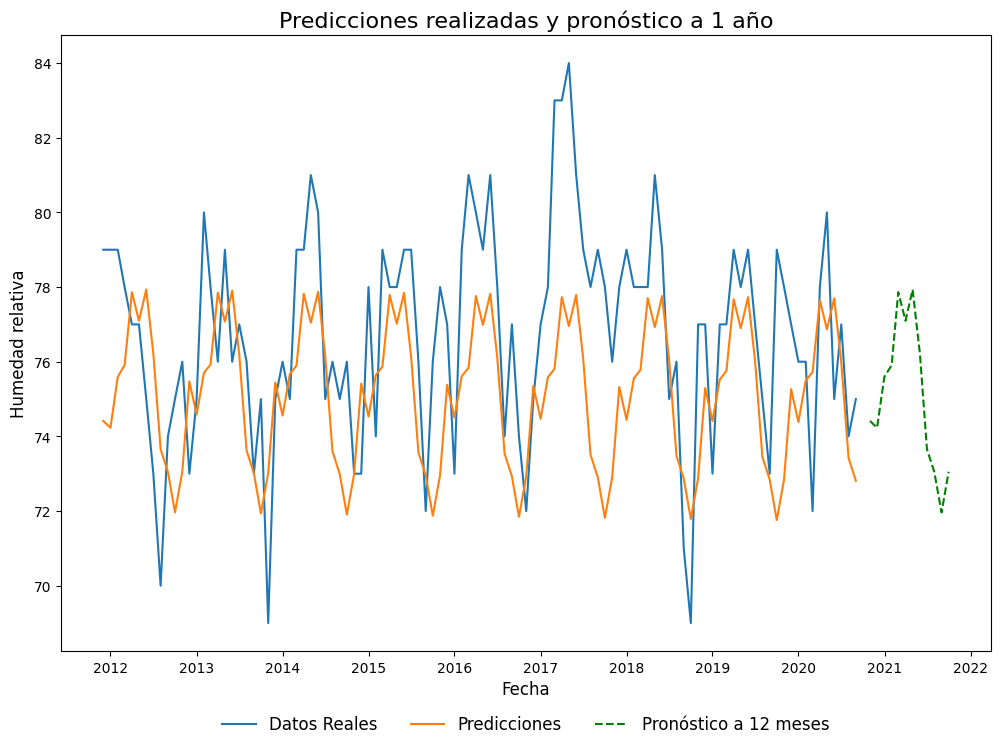

In [48]:
# PREDICCION A 1 AÑO

# Usar la función
fig, ax = plt.subplots(figsize=(12, 8))
title = 'Predicciones realizadas y pronóstico a 1 año'
xaxis = 'Fecha'
yaxis = 'Humedad relativa'
legend_title = '' 
fig = lineplot_predict_n_steps(test, model_fit, 12, title, xaxis, yaxis, legend_title, ax)

# Guardar figura
save_path = 'figs/humedad/model6.png'
plt.savefig(save_path) 

C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Bastian Barraza M\anaconda3\envs\personalFinances\lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is avai

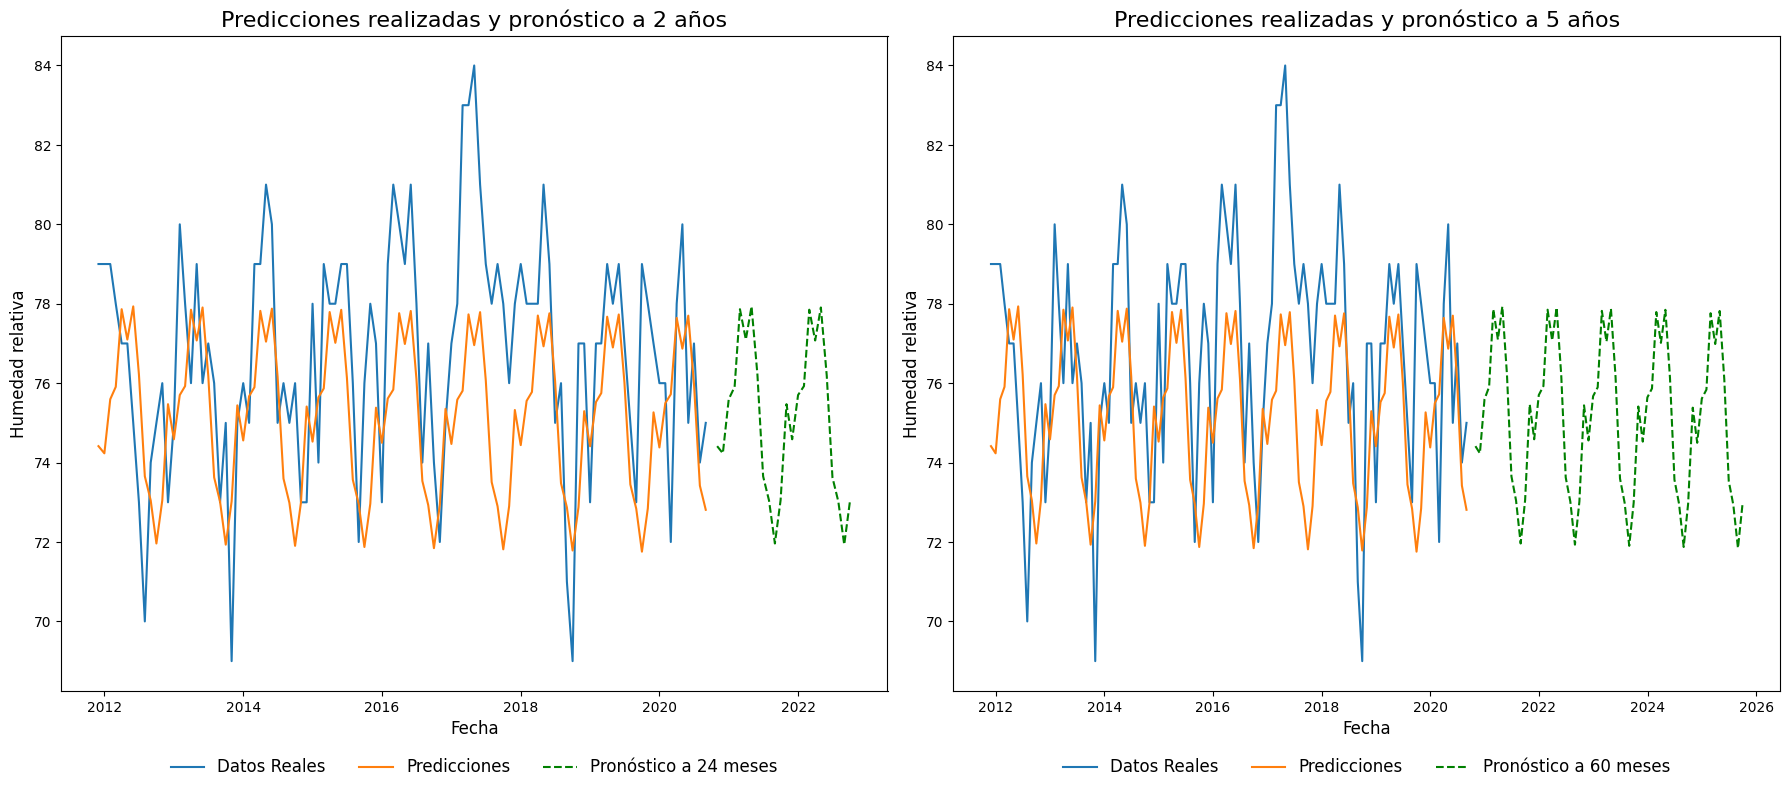

In [49]:
# Crear una figura con 2 subplots (1 fila, 2 columnas)
fig, axs = plt.subplots(1, 2, figsize=(18, 8))

# PREDICCION A 2 AÑOS

# Usar la función
title = 'Predicciones realizadas y pronóstico a 2 años'
xaxis = 'Fecha'
yaxis = 'Humedad relativa'
legend_title = '' 
fig = lineplot_predict_n_steps(test, model_fit, 24, title, xaxis, yaxis, legend_title, axs[0])

# PREDICCION A 5 AÑOS


# Usar la función
title = 'Predicciones realizadas y pronóstico a 5 años'
xaxis = 'Fecha'
yaxis = 'Humedad relativa'
legend_title = '' 
fig = lineplot_predict_n_steps(test, model_fit, 60, title, xaxis, yaxis, legend_title, axs[1])

# Ajustar layout para evitar solapamientos
plt.tight_layout()
save_path = 'figs/humedad/model7.png'
plt.savefig(save_path)